# Posterior Analysis

Posterior summaries, predictive checks on held-out data, and diagnostics on bayesian parameter estimation using emcee.

## Imports and plotting defaults
Load everything up front so each later section is self-contained.

In [1]:
import glob
import os
import pickle
import random
import re
import time
from collections import defaultdict

import analysis as flua
import corner
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm
from numba import carray, cfunc, njit, prange, types
from numba.experimental import jitclass
from numba.typed import List
from numbalsoda import address_as_void_pointer, lsoda
from scipy.stats import truncnorm

plt.rcParams["figure.dpi"] = 300


## Experiment metadata and priors
Light schedules used during training plus constants shared across the notebook.

In [2]:
TIMELAPSE_INFORMATION = {
    "TL240521": ["48HRS_GREEN_20PER", [0.20, 0.00]],
    "TL240523": ["48HRS_GREEN_40PER", [0.40, 0.00]],
    "TL240528": ["48HRS_GREEN_80PER", [0.80, 0.00]],
    "TL240530": ["48HRS_DARK", [0.00, 0.00]],
    "TL240607": ["48HRS_GREEN_RED_100PER", [1.00, 1.00]],
    "TL240610": ["48HRS_RED_50PER", [0.00, 0.50]],
    "TL240615": ["48HRS_RED_75PER", [0.00, 0.75]],
    "TL240716": ["48HRS_RED_10PER_GREEN_100PER", [1.00, 0.10]],
    "TL240719": ["48HRS_RED_10PER_GREEN_50PER", [0.50, 0.10]],
    "TL240727": ["48HRS_RED_10PER_GREEN_25PER", [0.25, 0.10]],
    "TL240801": ["48HRS_RED_20PER_GREEN_50PER", [0.50, 0.20]],
    "TL240804": ["48HRS_RED_30PER_GREEN_50PER", [0.50, 0.30]],
}

ROW_NAMES = [
    "roi",
    "time",
    "exp_data_means",
    "exp_data_stds",
    "t0_tf",
    "data_tpoints",
    "IA_0",
    "schedule_times",
    "schedule_R",
    "schedule_G",
    "schedule_R_COMPLETE",
    "schedule_G_COMPLETE",
    "firstswitch",
    "secondswitch",
    "dataset_name",
]

PRIOR_UNIFORM = 0
PRIOR_GAUSS = 1


## Data parsing and QC helpers
String-to-array parsing plus ROI filtering/patching for consistent downstream use.

In [3]:
def set_size(width, fraction=1, subplots=(1, 1)):
    """Return figure dimensions that play nicely with LaTeX."""

    if width == "thesis":
        width_pt = 426.79135
    elif width == "beamer":
        width_pt = 307.28987
    else:
        width_pt = width

    inches_per_pt = 1 / 72.27
    golden_ratio = (5**0.5 - 1) / 2
    fig_width_in = width_pt * fraction * inches_per_pt
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    return (fig_width_in, fig_height_in)


def parse_array_string(s: str) -> np.ndarray:
    """Convert a bracketed numeric string into a 1-D float array."""

    core = s.strip()
    if core.startswith("[") and core.endswith("]"):
        core = core[1:-1]

    number_regex = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"
    nums = re.findall(number_regex, core)
    return np.asarray(nums, dtype=np.float64)


def load_and_patch_dataset(
    csv_path: str,
    green_pct: float,
    red_pct: float,
    max_rois: int = 50,
    t_max_hours: int = 48,
    schedule_builder=None,
):
    """
    Clean a ROI table: filter out bad traces, trim to a target window, and rebuild schedules.
    If ``schedule_builder`` is provided, it should accept a 1-D time array and return
    ``(I_G_vec, I_R_vec)`` arrays of the same length for custom light regimes.
    Returns a patched DataFrame or ``None`` if nothing survives.
    """

    tmp_max_len = int(t_max_hours * 4)  # assumes ~15 min sampling by default
    zero_plateau = 80  # 20 h * 4 samples/h

    tmp = pd.read_csv(csv_path)
    tmp.index = ROW_NAMES[:-1]

    valid_cols = []
    for c in (col for col in tmp.columns if str(col).isdigit()):
        try:
            means_arr = parse_array_string(tmp.at["exp_data_means", c])
        except Exception as err:  # noqa: BLE001
            print(f"WARNING {csv_path} ROI {c}: parse error ({err}) - skipped.")
            continue

        if np.any(means_arr < 0):
            continue

        if means_arr.size == 0:
            continue

        if means_arr.size > zero_plateau and np.any(means_arr[zero_plateau:] == 0):
            continue

        valid_cols.append(c)

    if not valid_cols:
        print(f"WARNING {csv_path}: no ROI passed the QC filters - skipped.")
        return None

    sampled_cols = random.sample(valid_cols, min(max_rois, len(valid_cols)))
    tmp = tmp[sampled_cols]

    for c in sampled_cols:
        time_arr = parse_array_string(tmp.at["time", c])
        means_arr = parse_array_string(tmp.at["exp_data_means", c])
        stds_arr = parse_array_string(tmp.at["exp_data_stds", c])
        data_tpts = parse_array_string(tmp.at["data_tpoints", c])

        if time_arr.size > tmp_max_len:
            slice_ = slice(0, tmp_max_len)
            time_arr = time_arr[slice_]
            means_arr = means_arr[slice_]
            stds_arr = stds_arr[slice_]
            data_tpts = data_tpts[slice_]

            fs_arr = parse_array_string(tmp.at["firstswitch", c])[:tmp_max_len]
            ss_arr = parse_array_string(tmp.at["secondswitch", c])[:tmp_max_len]
            tmp.at["firstswitch", c] = str(list(fs_arr))
            tmp.at["secondswitch", c] = str(list(ss_arr))

            t0_tf = parse_array_string(tmp.at["t0_tf", c])
            t0_tf[1] = time_arr[-1]
            tmp.at["t0_tf", c] = str(list(t0_tf))

        tmp.at["time", c] = str(list(time_arr))
        tmp.at["exp_data_means", c] = str(list(means_arr))
        tmp.at["exp_data_stds", c] = str(list(stds_arr))
        tmp.at["data_tpoints", c] = str(list(data_tpts))

        if schedule_builder is not None:
            I_G_vec, I_R_vec = schedule_builder(time_arr)
            I_G_vec = np.asarray(I_G_vec, dtype=np.float64)
            I_R_vec = np.asarray(I_R_vec, dtype=np.float64)

            if I_G_vec.shape != time_arr.shape or I_R_vec.shape != time_arr.shape:
                raise ValueError("schedule_builder must return arrays matching 'time'.")

            tmp.at["schedule_R_COMPLETE", c] = str(list(I_R_vec))
            tmp.at["schedule_G_COMPLETE", c] = str(list(I_G_vec))
            tmp.at["schedule_R", c] = str(list(np.unique(I_R_vec)))
            tmp.at["schedule_G", c] = str(list(np.unique(I_G_vec)))
        else:
            n_tpts = time_arr.size
            red_vec = str(list(np.full(n_tpts, red_pct)))
            green_vec = str(list(np.full(n_tpts, green_pct)))

            tmp.at["schedule_R_COMPLETE", c] = red_vec
            tmp.at["schedule_G_COMPLETE", c] = green_vec
            tmp.at["schedule_R", c] = str([red_pct])
            tmp.at["schedule_G", c] = str([green_pct])

    dataset_key = os.path.basename(csv_path).split("_")[-1].split(".")[0]
    tmp.loc["dataset_name"] = dataset_key

    return tmp


## Light schedule utilities
Helper to derive per-experiment light inputs for simulation.

In [4]:
def lookup_light_schedule(exp_id: str, t: np.ndarray):
    """Return green/red intensity vectors for a training experiment."""

    try:
        green_frac, red_frac = TIMELAPSE_INFORMATION[exp_id][1]
    except KeyError as exc:
        raise ValueError(f"Unknown experiment ID '{exp_id}'.") from exc

    I_G = np.full_like(t, green_frac, dtype=np.float64)
    I_R = np.full_like(t, red_frac, dtype=np.float64)
    return I_G, I_R


def build_piecewise_light_schedule(t: np.ndarray, segments):
    """
    Build green/red intensity vectors for a piecewise schedule.

    Parameters
    ----------
    t : np.ndarray
        Time vector (hours).
    segments : iterable of (end_time, green_frac, red_frac)
        Each tuple sets the intensities up to ``end_time`` (in hours).
        Use ``np.inf`` for the last ``end_time`` to cover the tail.
    """

    if not segments:
        raise ValueError("segments must be a non-empty sequence.")

    t_arr = np.asarray(t, dtype=np.float64)
    I_G = np.zeros_like(t_arr)
    I_R = np.zeros_like(t_arr)

    current_start = t_arr[0] if t_arr.size else 0.0
    for end_time, g_val, r_val in segments:
        mask = (t_arr >= current_start) & (t_arr < end_time)
        I_G[mask] = g_val
        I_R[mask] = r_val
        current_start = end_time

    last_g, last_r = segments[-1][1], segments[-1][2]
    I_G[t_arr >= current_start] = last_g
    I_R[t_arr >= current_start] = last_r
    return I_G, I_R


## ODE model and solver wrappers
Numba-accelerated forward model used throughout posterior sampling and checks.

In [5]:
@njit(inline="always")
def faster_light_interp(t_val, t_start, time_step, g_arr, r_arr):
    """Fast O(1) interpolation of light intensity."""

    idx = int((t_val - t_start) / time_step)
    safe_idx = min(max(0, idx), g_arr.size - 1)
    return g_arr[safe_idx], r_arr[safe_idx]


user_data_dtype = types.Record.make_c_struct(
    [
        ("p_p", types.int64),
        ("len_p", types.int64),
        ("g_light_p", types.int64),
        ("len_g_light", types.int64),
        ("r_light_p", types.int64),
        ("len_r_light", types.int64),
        ("t_start", types.float64),
        ("time_step", types.float64),
    ]
)

roi_spec = [
    ("t", types.float64[:]),
    ("y", types.float64[:]),
    ("u0", types.float64[:]),
    ("I_G", types.float64[:]),
    ("I_R", types.float64[:]),
    ("t_start", types.float64),
    ("time_step", types.float64),
]


@jitclass(roi_spec)
class ROIData:
    def __init__(self, t, y, u0, I_G, I_R, t_start, time_step):
        self.t = t
        self.y = y
        self.u0 = u0
        self.I_G = I_G
        self.I_R = I_R
        self.t_start = t_start
        self.time_step = time_step


@njit
def run_forward_model(theta_lin, roi_data, funcptr):
    """Solve the ODE for one ROI and one parameter vector."""

    user_data = np.empty(1, dtype=user_data_dtype)
    user_data[0].p_p = np.int64(theta_lin.ctypes.data)
    user_data[0].len_p = theta_lin.size
    user_data[0].g_light_p = np.int64(roi_data.I_G.ctypes.data)
    user_data[0].len_g_light = roi_data.I_G.size
    user_data[0].r_light_p = np.int64(roi_data.I_R.ctypes.data)
    user_data[0].len_r_light = roi_data.I_R.size
    user_data[0].t_start = roi_data.t_start
    user_data[0].time_step = roi_data.time_step

    sol, success = lsoda(
        funcptr, roi_data.u0, roi_data.t, data=user_data, atol=1e-8, rtol=1e-8
    )

    if success and np.all(np.isfinite(sol)):
        return sol.flatten()

    return np.full_like(roi_data.t, np.nan)


def create_wrapped_rhs(rhs_func, args_dtype):
    """Wrap a Numba RHS as a C-callable function for lsoda."""

    jitted_rhs = njit(rhs_func)
    cfunc_sig = types.void(
        types.double,
        types.CPointer(types.double),
        types.CPointer(types.double),
        types.CPointer(args_dtype),
    )

    @cfunc(cfunc_sig, nopython=True)
    def wrapped_rhs(t, u, du, user_data_p):
        user_data = carray(user_data_p, 1)[0]
        p = carray(
            address_as_void_pointer(user_data.p_p), (user_data.len_p,), dtype=np.float64
        )
        g_light = carray(
            address_as_void_pointer(user_data.g_light_p),
            (user_data.len_g_light,),
            dtype=np.float64,
        )
        r_light = carray(
            address_as_void_pointer(user_data.r_light_p),
            (user_data.len_r_light,),
            dtype=np.float64,
        )
        jitted_rhs(
            t,
            u,
            du,
            p,
            g_light,
            r_light,
            user_data.t_start,
            user_data.time_step,
        )

    return wrapped_rhs


def dIAdt_reduced(t, u, du, p, g_light, r_light, t_start, time_step):
    """Reduced ODE model with faster interpolation."""

    I_G, I_R = faster_light_interp(t, t_start, time_step, g_light, r_light)
    a1, d_p, mu_max, t_half, a3, a4, a5, a6 = p
    a2 = d_p + mu_max / (1 + np.exp(mu_max * (t - t_half)))
    prod = (I_G * a3 + 1) / (a3 * a5 * I_G + a4 * a6 + a4 * I_R + a5)
    du[0] = a1 + prod - a2 * u[0]


funcptr_reduced = create_wrapped_rhs(dIAdt_reduced, user_data_dtype)


def solve_model(theta_lin, t_vec, u0, I_G_vec, I_R_vec, model="reduced"):
    """Convenience wrapper to solve the ODE for a given setup."""

    if model != "reduced":
        raise ValueError("Only 'reduced' model is currently configured.")

    p = np.ascontiguousarray(theta_lin, dtype=np.float64)
    t_light = np.ascontiguousarray(t_vec, dtype=np.float64)
    g_light = np.ascontiguousarray(I_G_vec, dtype=np.float64)
    r_light = np.ascontiguousarray(I_R_vec, dtype=np.float64)

    user_data = np.array(
        [
            (
                p.ctypes.data,
                p.size,
                t_light.ctypes.data,
                t_light.size,
                g_light.ctypes.data,
                g_light.size,
                r_light.ctypes.data,
                r_light.size,
            )
        ],
        dtype=user_data_dtype,
    )

    sol, _ = lsoda(
        funcptr_reduced.address, u0, t_vec, data=user_data, atol=1e-8, rtol=1e-8
    )
    return sol.flatten()


## Log-probability helpers for MCMC
Parallelizable likelihood/prior pieces and walker initialization.

In [6]:
@njit(fastmath=True)
def convert_to_log_bounds_nb(lower, upper):
    return np.log10(lower), np.log10(upper)


@njit(fastmath=True)
def log_prior_mixed_nb(p_log, lower_log, upper_log, modes, mu_log, sig_log):
    logp = 0.0
    for i in range(p_log.size):
        if not (lower_log[i] <= p_log[i] <= upper_log[i]):
            return -np.inf
        if modes[i] == PRIOR_GAUSS:
            diff = p_log[i] - mu_log[i]
            logp += -0.5 * (diff / sig_log[i]) ** 2
    return logp


@njit(fastmath=True)
def log_likelihood_nb_jit(y_model, y_data, log_sigma):
    sigma_sq = (10**log_sigma) ** 2
    return -0.5 * np.sum(
        (y_model - y_data) ** 2 / sigma_sq + np.log(2 * np.pi * sigma_sq)
    )


@njit(parallel=True)
def parallel_log_prob(
    theta_log, lower_log, upper_log, prior_modes, mu_log, sig_log, big_dataset, funcptr
):
    logp = 0.0
    for i in range(theta_log.size):
        if not (lower_log[i] <= theta_log[i] <= upper_log[i]):
            return -np.inf
        if prior_modes[i] == PRIOR_GAUSS:
            diff = theta_log[i] - mu_log[i]
            logp += -0.5 * (diff / sig_log[i]) ** 2

    theta_lin = 10.0 ** theta_log[:-1]
    log_sigma = theta_log[-1]
    sigma_sq = (10**log_sigma) ** 2
    log_sigma_term = np.log(2 * np.pi * sigma_sq)

    ll = 0.0
    solve_failed = np.zeros(1, dtype=np.bool_)

    for i in prange(len(big_dataset)):
        if solve_failed[0]:
            continue

        rec = big_dataset[i]

        user_data = np.empty(1, dtype=user_data_dtype)
        user_data[0].p_p = np.int64(theta_lin.ctypes.data)
        user_data[0].len_p = theta_lin.size
        user_data[0].g_light_p = np.int64(rec.I_G.ctypes.data)
        user_data[0].len_g_light = rec.I_G.size
        user_data[0].r_light_p = np.int64(rec.I_R.ctypes.data)
        user_data[0].len_r_light = rec.I_R.size
        user_data[0].t_start = rec.t_start
        user_data[0].time_step = rec.time_step

        sol, success = lsoda(
            funcptr, rec.u0, rec.t, data=user_data, atol=1e-8, rtol=1e-8
        )

        if not success or not np.all(np.isfinite(sol)):
            solve_failed[0] = True
            continue

        y_model = sol.flatten()
        if y_model.shape == rec.y.shape:
            residual_sq = (y_model - rec.y) ** 2
            ll += -0.5 * np.sum(residual_sq / sigma_sq + log_sigma_term)
        else:
            solve_failed[0] = True
            continue

    if solve_failed[0]:
        return -np.inf

    return logp + ll


def log_prob_parallel_wrapper(
    theta_log, lower_log, upper_log, big_dataset, prior_modes, mu_log, sig_log, funcptr
):
    return parallel_log_prob(
        theta_log,
        lower_log,
        upper_log,
        prior_modes,
        mu_log,
        sig_log,
        big_dataset,
        funcptr,
    )


def make_initial_walkers(
    nwalkers, lower_log, upper_log, prior_modes, mu_log, sig_log, rng
):
    ndim = lower_log.size
    walkers = np.empty((nwalkers, ndim), dtype=np.float64)
    for j in range(ndim):
        lo, hi = lower_log[j], upper_log[j]
        if prior_modes[j] == PRIOR_UNIFORM:
            walkers[:, j] = rng.uniform(lo, hi, size=nwalkers)
        elif prior_modes[j] == PRIOR_GAUSS:
            scale = max(sig_log[j], 1e-10)
            a, b = (lo - mu_log[j]) / scale, (hi - mu_log[j]) / scale
            walkers[:, j] = truncnorm(a, b, loc=mu_log[j], scale=scale).rvs(
                size=nwalkers, random_state=rng
            )
    return walkers


## Load posterior samples
Pull the emcee sampler from disk and back-transform to linear space.

In [7]:
#sampler_path = r"/Users/adaravena/Library/CloudStorage/GoogleDrive-adaravena94@gmail.com/My Drive/Optogenetics_JUN2025/fluopti_fits/data_analysis/MCMC_07112025_UNIFORMPRIORS_WITH_ZEROVALS.pkl"
sampler_path = r"G:\\My Drive\\Optogenetics_JUN2025\\fluopti_fits\data_analysis\\MCMC_07112025_UNIFORMPRIORS_WITH_ZEROVALS.pkl"

with open(sampler_path, "rb") as f:
    sampler = pickle.load(f)

burnin = 5_000
flat_samples_log = sampler.get_chain(discard=burnin, flat=True)
print(
    "Shape of flattened log samples after burn-in and thinning:", flat_samples_log.shape
)

flat_samples_linear = 10**flat_samples_log
print("Samples successfully back-transformed to linear space.")

param_labels_linear = [
    "a1",
    "d_p",
    "mu_max",
    "t_half",
    "a3",
    "a4",
    "a5",
    "a6",
    "sigma",
]


Shape of flattened log samples after burn-in and thinning: (12960000, 9)
Samples successfully back-transformed to linear space.


## Corner plot log space
Visualize posterior for model parameters (excluding sigma) in log10 units.

In [ ]:
print(
    "Generating corner plot for model parameters only (excluding sigma) in log space..."
)

model_samples_log = flat_samples_log[:, :-1]
model_param_labels_log = [f"log10({param})" for param in param_labels_linear[:-1]]

fig_model_log = corner.corner(
    model_samples_log,
    labels=model_param_labels_log,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
)
plt.suptitle("Model Parameters Posterior Distribution (Log Space)", fontsize=14, y=0.98)
plt.show()

print("\n--- Model Parameters Only (50th percentile +/- 1 sigma) [Log Space] ---")
for i in range(model_samples_log.shape[1]):
    mcmc = np.percentile(model_samples_log[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{model_param_labels_log[i]:>16}: {mcmc[1]:.3f} [-{q[0]:.3f}, +{q[1]:.3f}]")

fig_model_log.savefig(
    "GEMINI_VERSION_corner_plot_log_space_12112025_UNIFORMPRIORS_WITHOUTZEROVALS.png",
    dpi=300,
)
fig_model_log.savefig(
    "GEMINI_VERSION_corner_plot_log_space_12112025_UNIFORMPRIORS_WITHOUTZEROVALS.pdf"
)
print(
    "Corner plot saved as 'GEMINI_VERSION_corner_plot_log_space_12112025_UNIFORMPRIORS_WITHOUTZEROVALS.png'."
)


## Corner plot linear space
Same visualization in linear units for readability of raw parameter scales.

In [ ]:
print(
    "Generating corner plot for model parameters only (excluding sigma) in linear space..."
)

model_samples_lin = flat_samples_linear[:, :-1]
model_param_labels_lin = param_labels_linear[:-1]

fig_model_lin = corner.corner(
    model_samples_lin,
    labels=model_param_labels_lin,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
)

plt.suptitle("Model Parameters Posterior Distribution", fontsize=14, y=0.98)
plt.show()

print("\n--- Model Parameters Only (50th percentile +/- 1 sigma) [Linear Space] ---")
for i in range(model_samples_lin.shape[1]):
    mcmc = np.percentile(model_samples_lin[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{model_param_labels_lin[i]:>10}: {mcmc[1]:.6f} [-{q[0]:.6f}, +{q[1]:.6f}]")

fig_model_lin.savefig(
    "GEMINI_VERSION_corner_plot_linear_space_12112025_UNIFORMPRIORS.png", dpi=300
)
fig_model_lin.savefig(
    "GEMINI_VERSION_corner_plot_linear_space_12112025_UNIFORMPRIORS.pdf"
)
print(
    "Corner plot saved as 'GEMINI_VERSION_corner_plot_linear_space_12112025_UNIFORMPRIORS.png'."
)


## Parameter credible intervals
Summaries for each parameter (median and 95% credible interval).

In [8]:
percentiles = [2.5, 50, 97.5]
param_stats = np.percentile(flat_samples_linear, percentiles, axis=0)

results_dict = {
    "Parameter": param_labels_linear,
    "MAP (Median)": param_stats[1],
    "CI Lower (2.5%)": param_stats[0],
    "CI Upper (97.5%)": param_stats[2],
}

results_df = pd.DataFrame(results_dict)
results_df.set_index("Parameter", inplace=True)

print("--- Parameter Estimates (MAP and 95% Credible Intervals) ---")
print(results_df.to_string(float_format="%.4f"))

print("\n--- Detailed Summary ---")
for i, param_name in enumerate(param_labels_linear):
    map_estimate = param_stats[1, i]
    lower_bound = param_stats[0, i]
    upper_bound = param_stats[2, i]
    print(
        f"{param_name:>10}: {map_estimate:.4f}  [95% CI: ({lower_bound:.4f}, {upper_bound:.4f})]"
    )


--- Parameter Estimates (MAP and 95% Credible Intervals) ---
           MAP (Median)  CI Lower (2.5%)  CI Upper (97.5%)
Parameter                                                 
a1               0.0000           0.0000            0.0000
d_p              0.1305           0.1302            0.1308
mu_max          12.4460          11.9655           12.9632
t_half          13.5593          13.5489           13.5697
a3               1.4906           1.4794            1.5017
a4               0.2879           0.2869            0.2889
a5               0.0507           0.0505            0.0508
a6               0.0219           0.0215            0.0222
sigma            5.0000           5.0000            5.0000

--- Detailed Summary ---
        a1: 0.0000  [95% CI: (0.0000, 0.0000)]
       d_p: 0.1305  [95% CI: (0.1302, 0.1308)]
    mu_max: 12.4460  [95% CI: (11.9655, 12.9632)]
    t_half: 13.5593  [95% CI: (13.5489, 13.5697)]
        a3: 1.4906  [95% CI: (1.4794, 1.5017)]
        a4: 0.2879  [95

## Prepare training ROI dataset
Load aggregated ROI data into Numba-friendly structures and sketch posterior samples against training traces.

Current directory: G:\My Drive\Optogenetics_JUN2025\fluopti_fits


Pre-processing ROI data: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 867/867 [00:00<00:00, 970.84it/s] 


Loaded and cached 867 colony traces into Numba-ready format.


Plotting ROI 259: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1000/1000 [00:01<00:00, 711.63it/s]


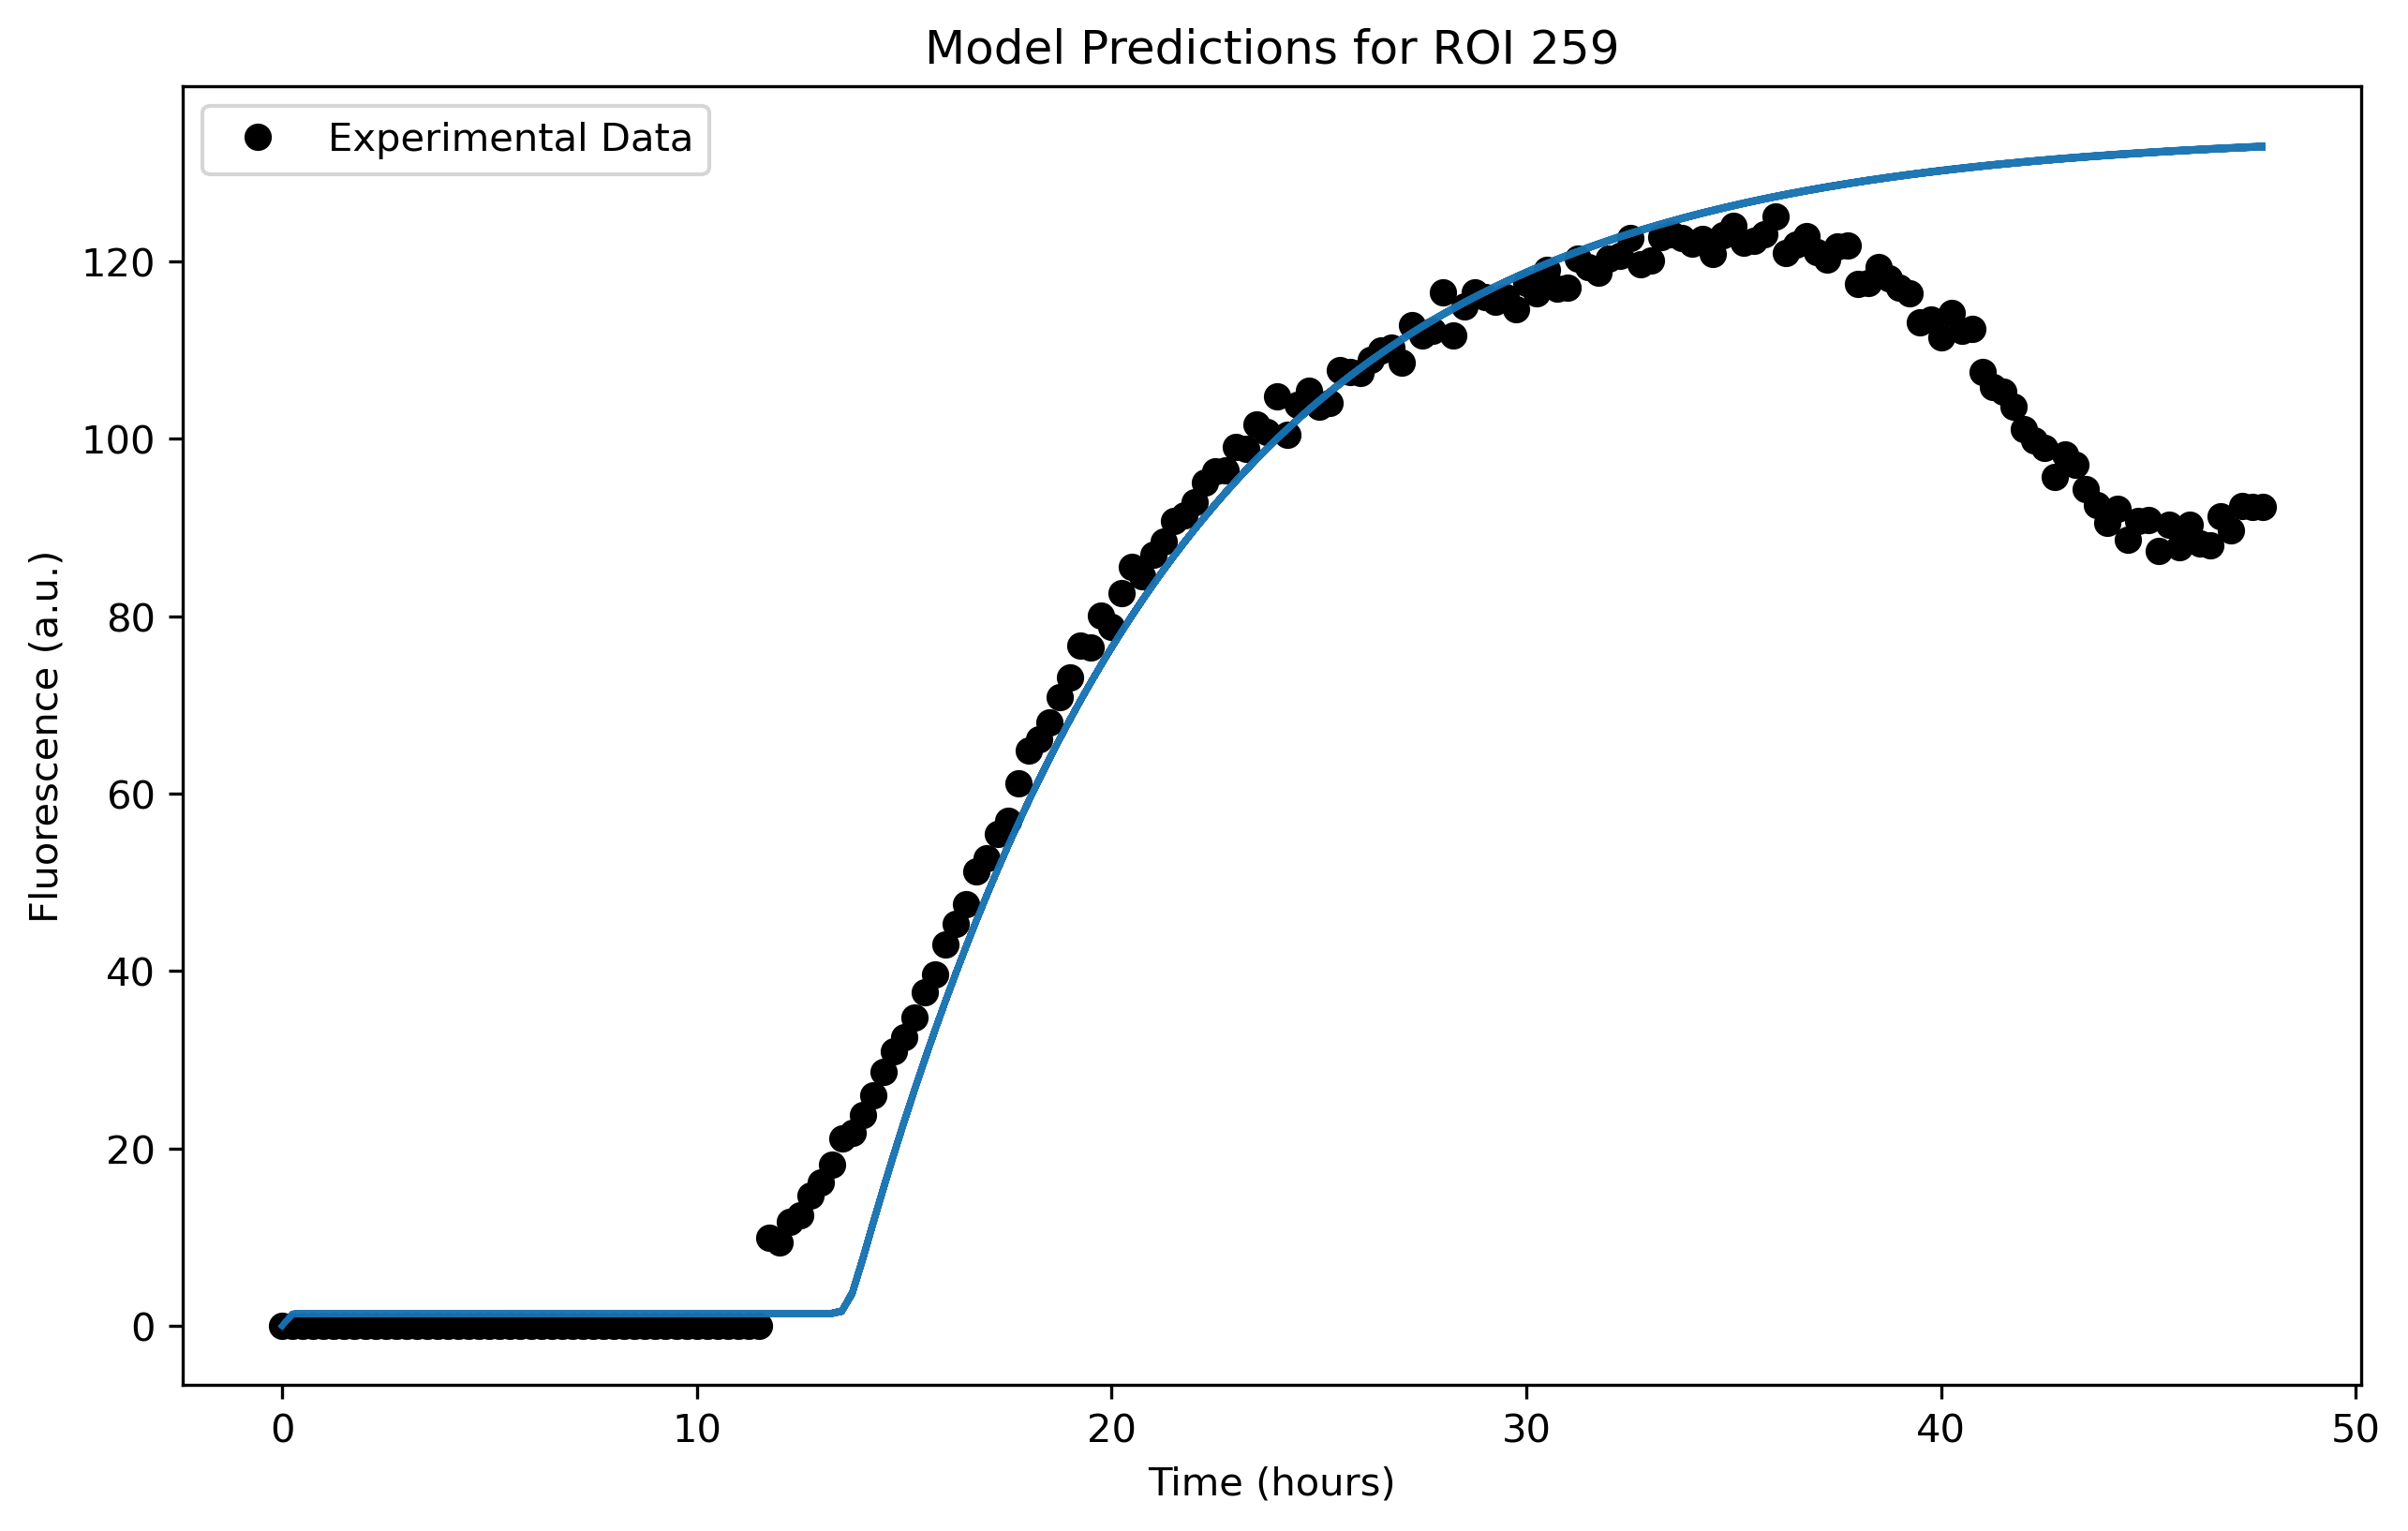

Plotting ROI 447: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1000/1000 [00:00<00:00, 2894.34it/s]


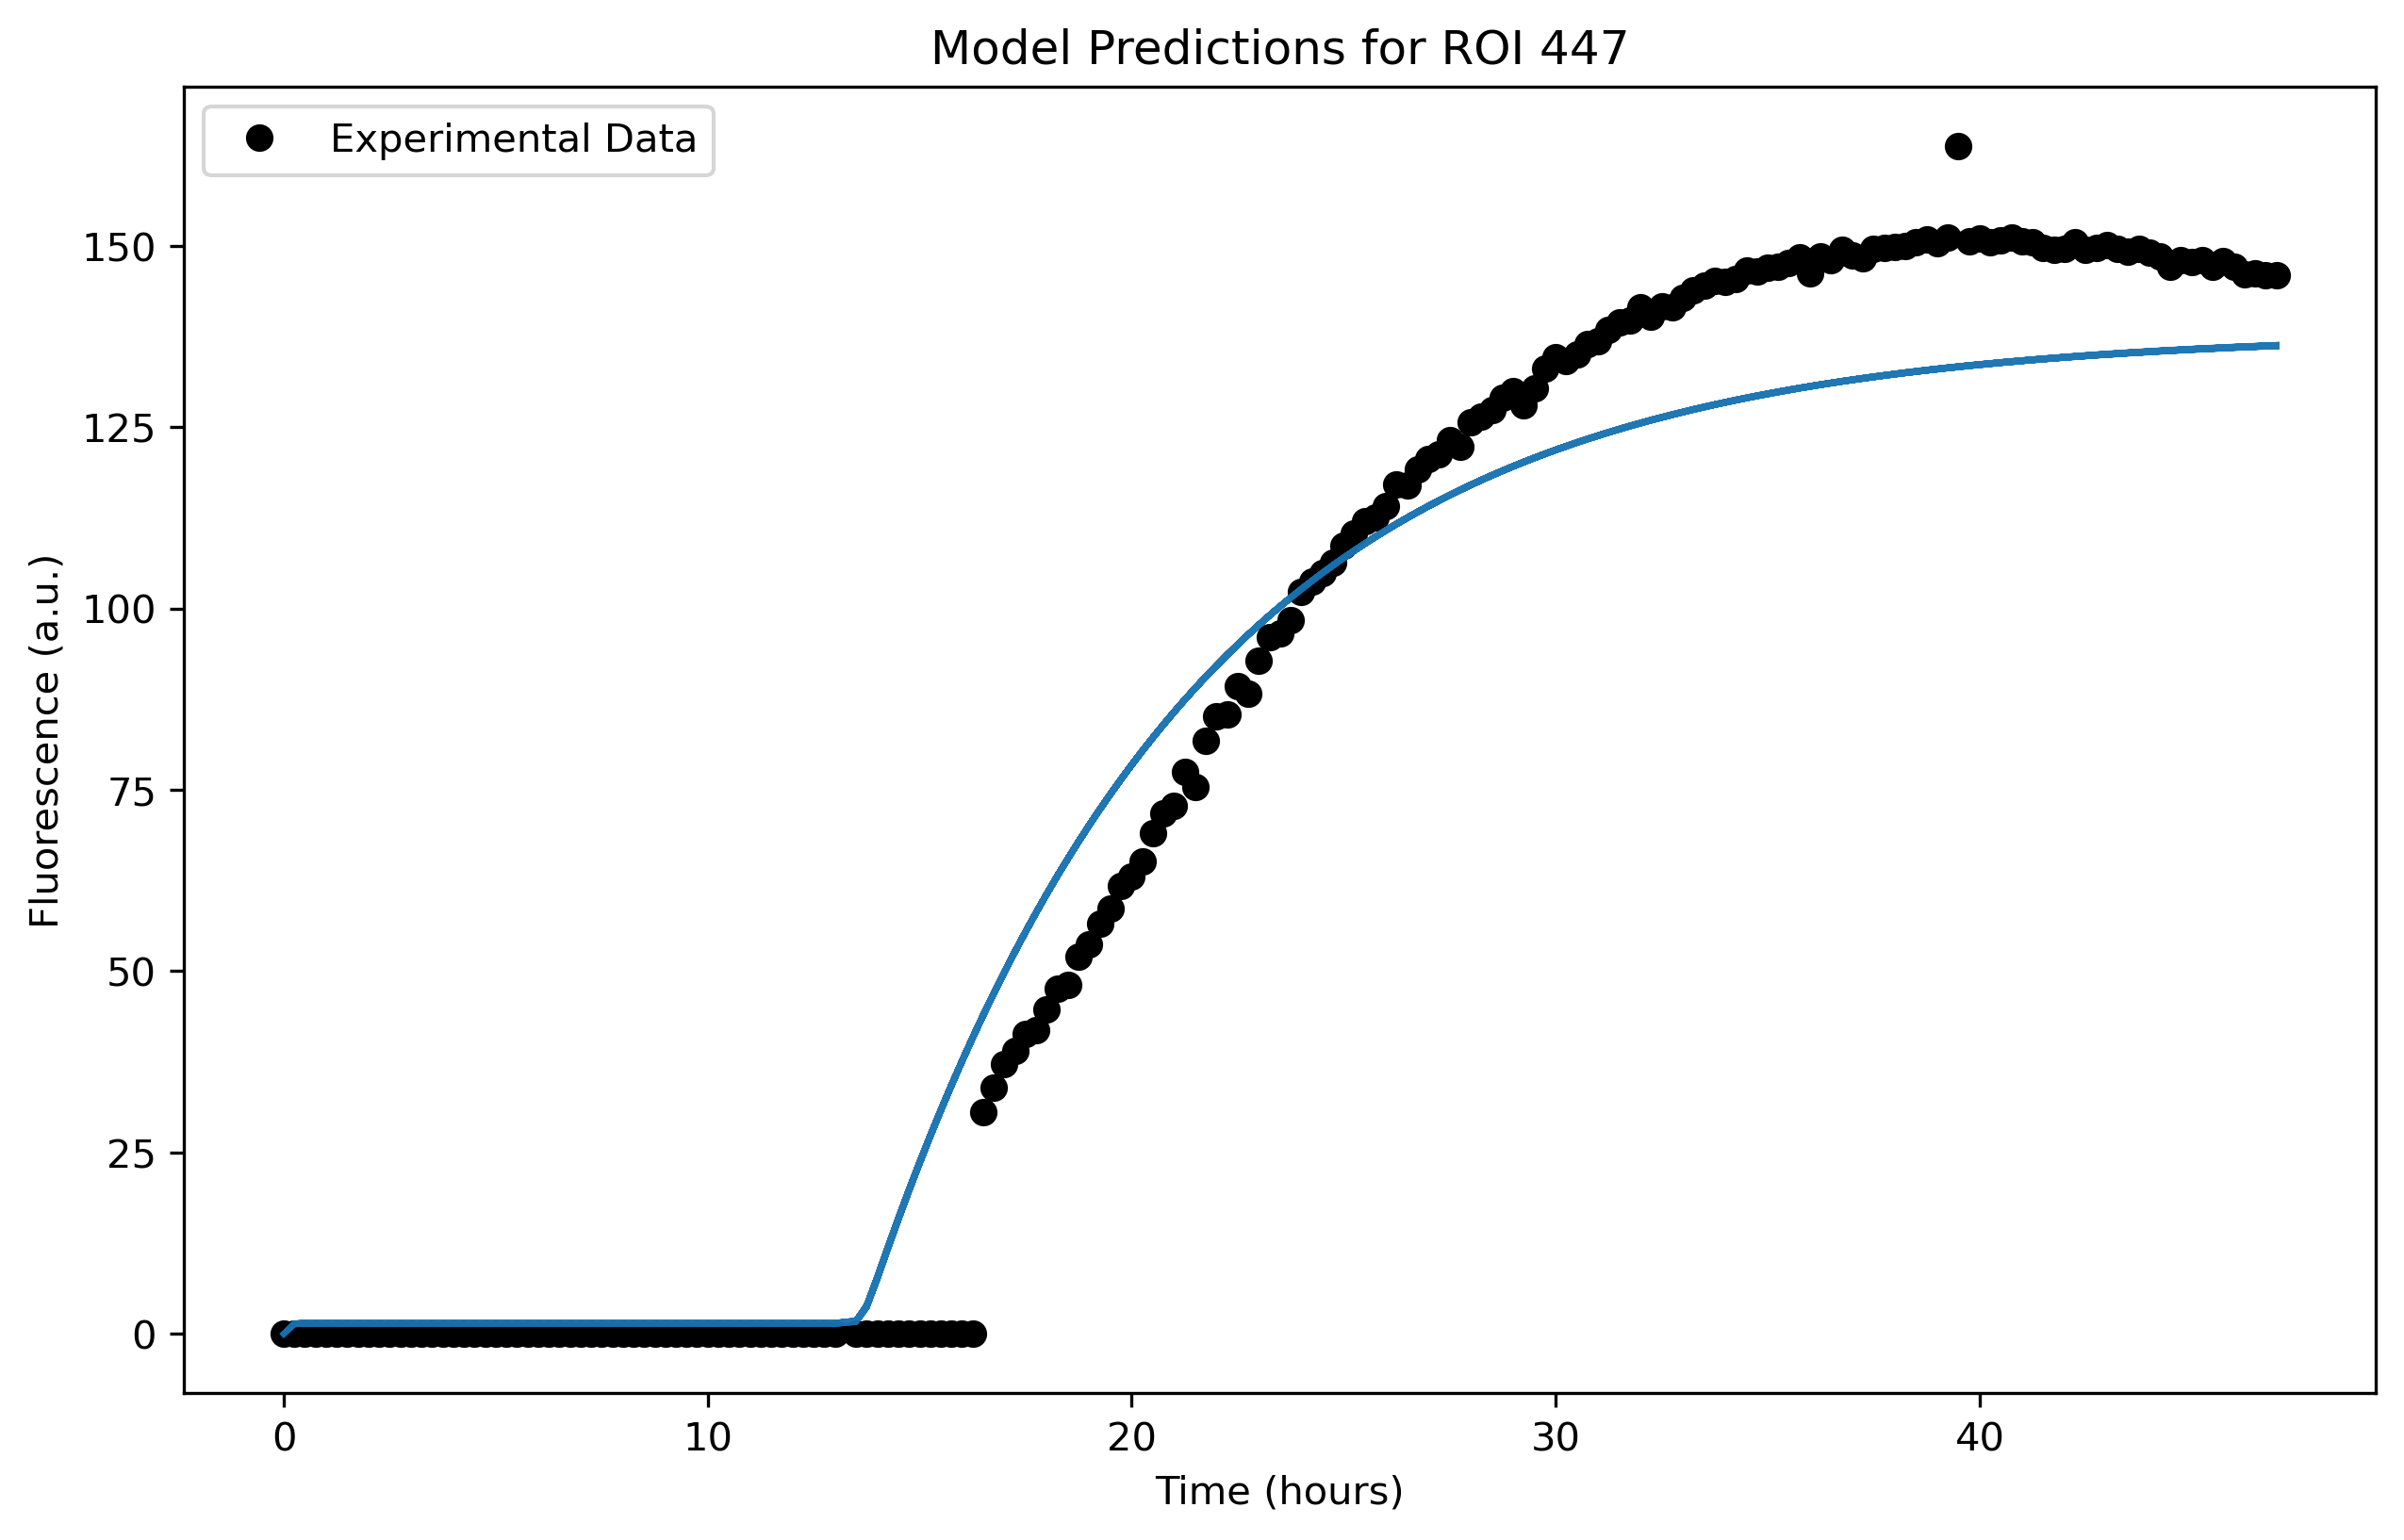

Plotting ROI 333: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1000/1000 [00:00<00:00, 1840.07it/s]


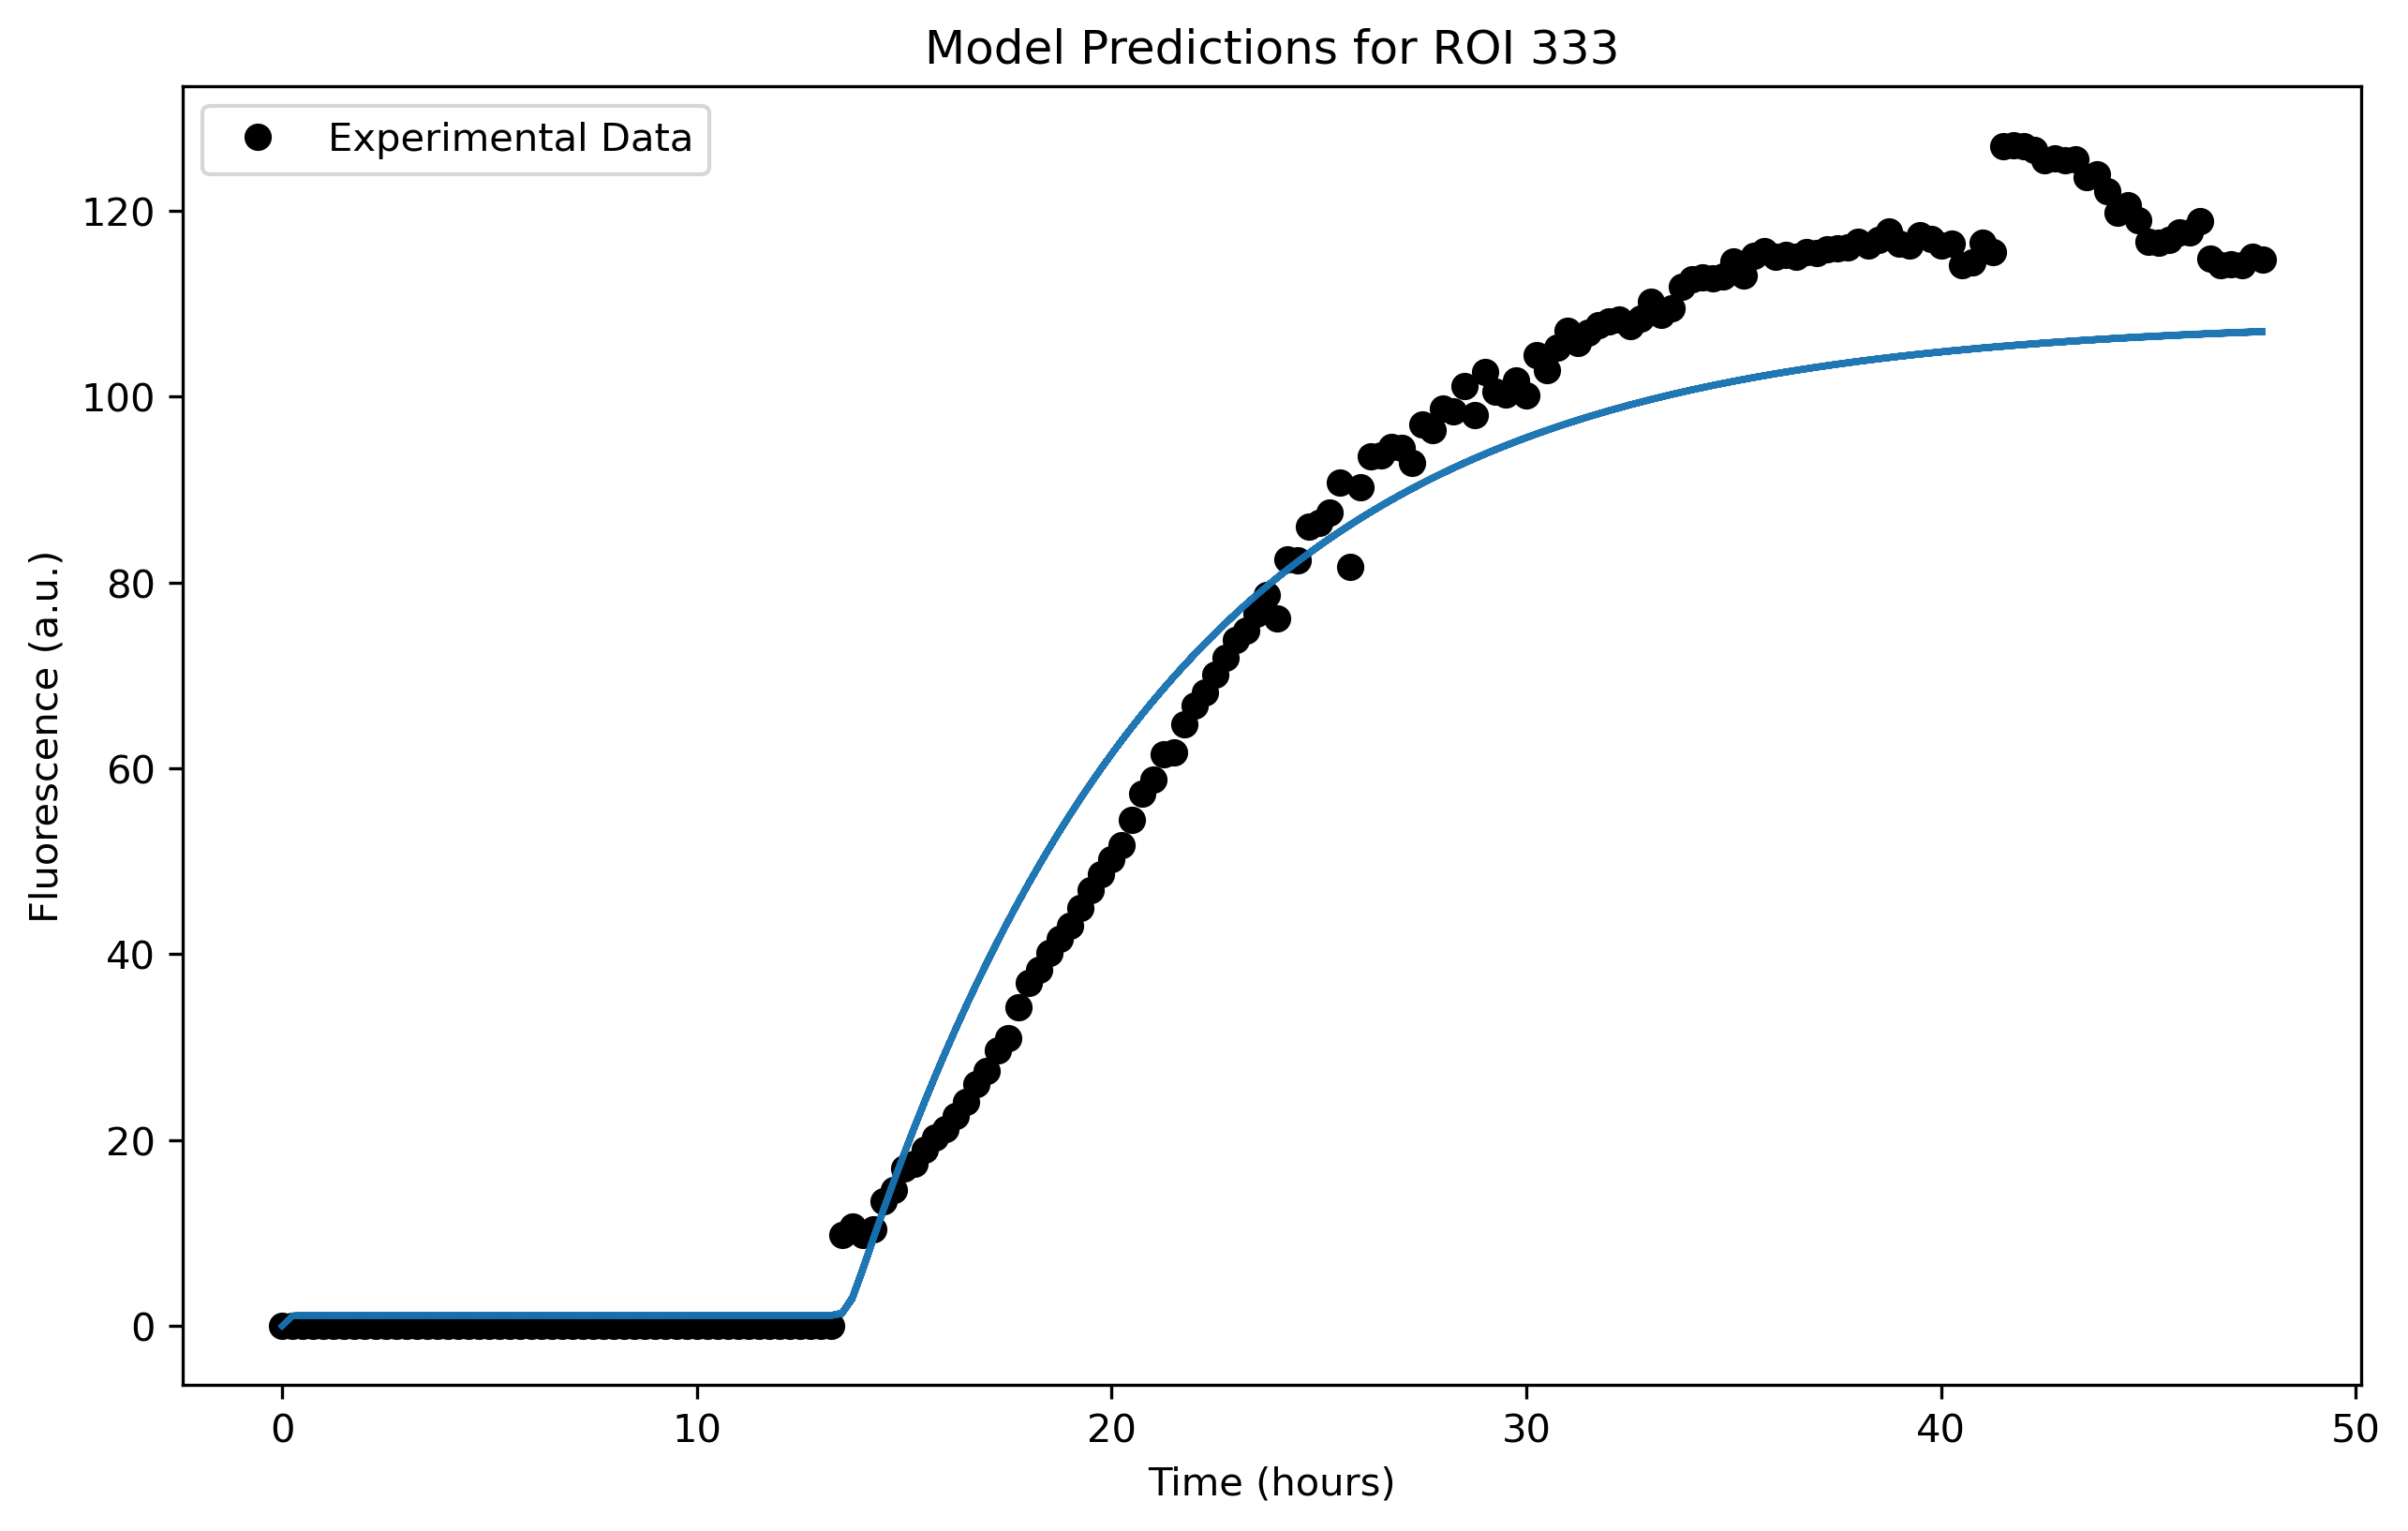

Plotting ROI 454: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1000/1000 [00:00<00:00, 2939.95it/s]


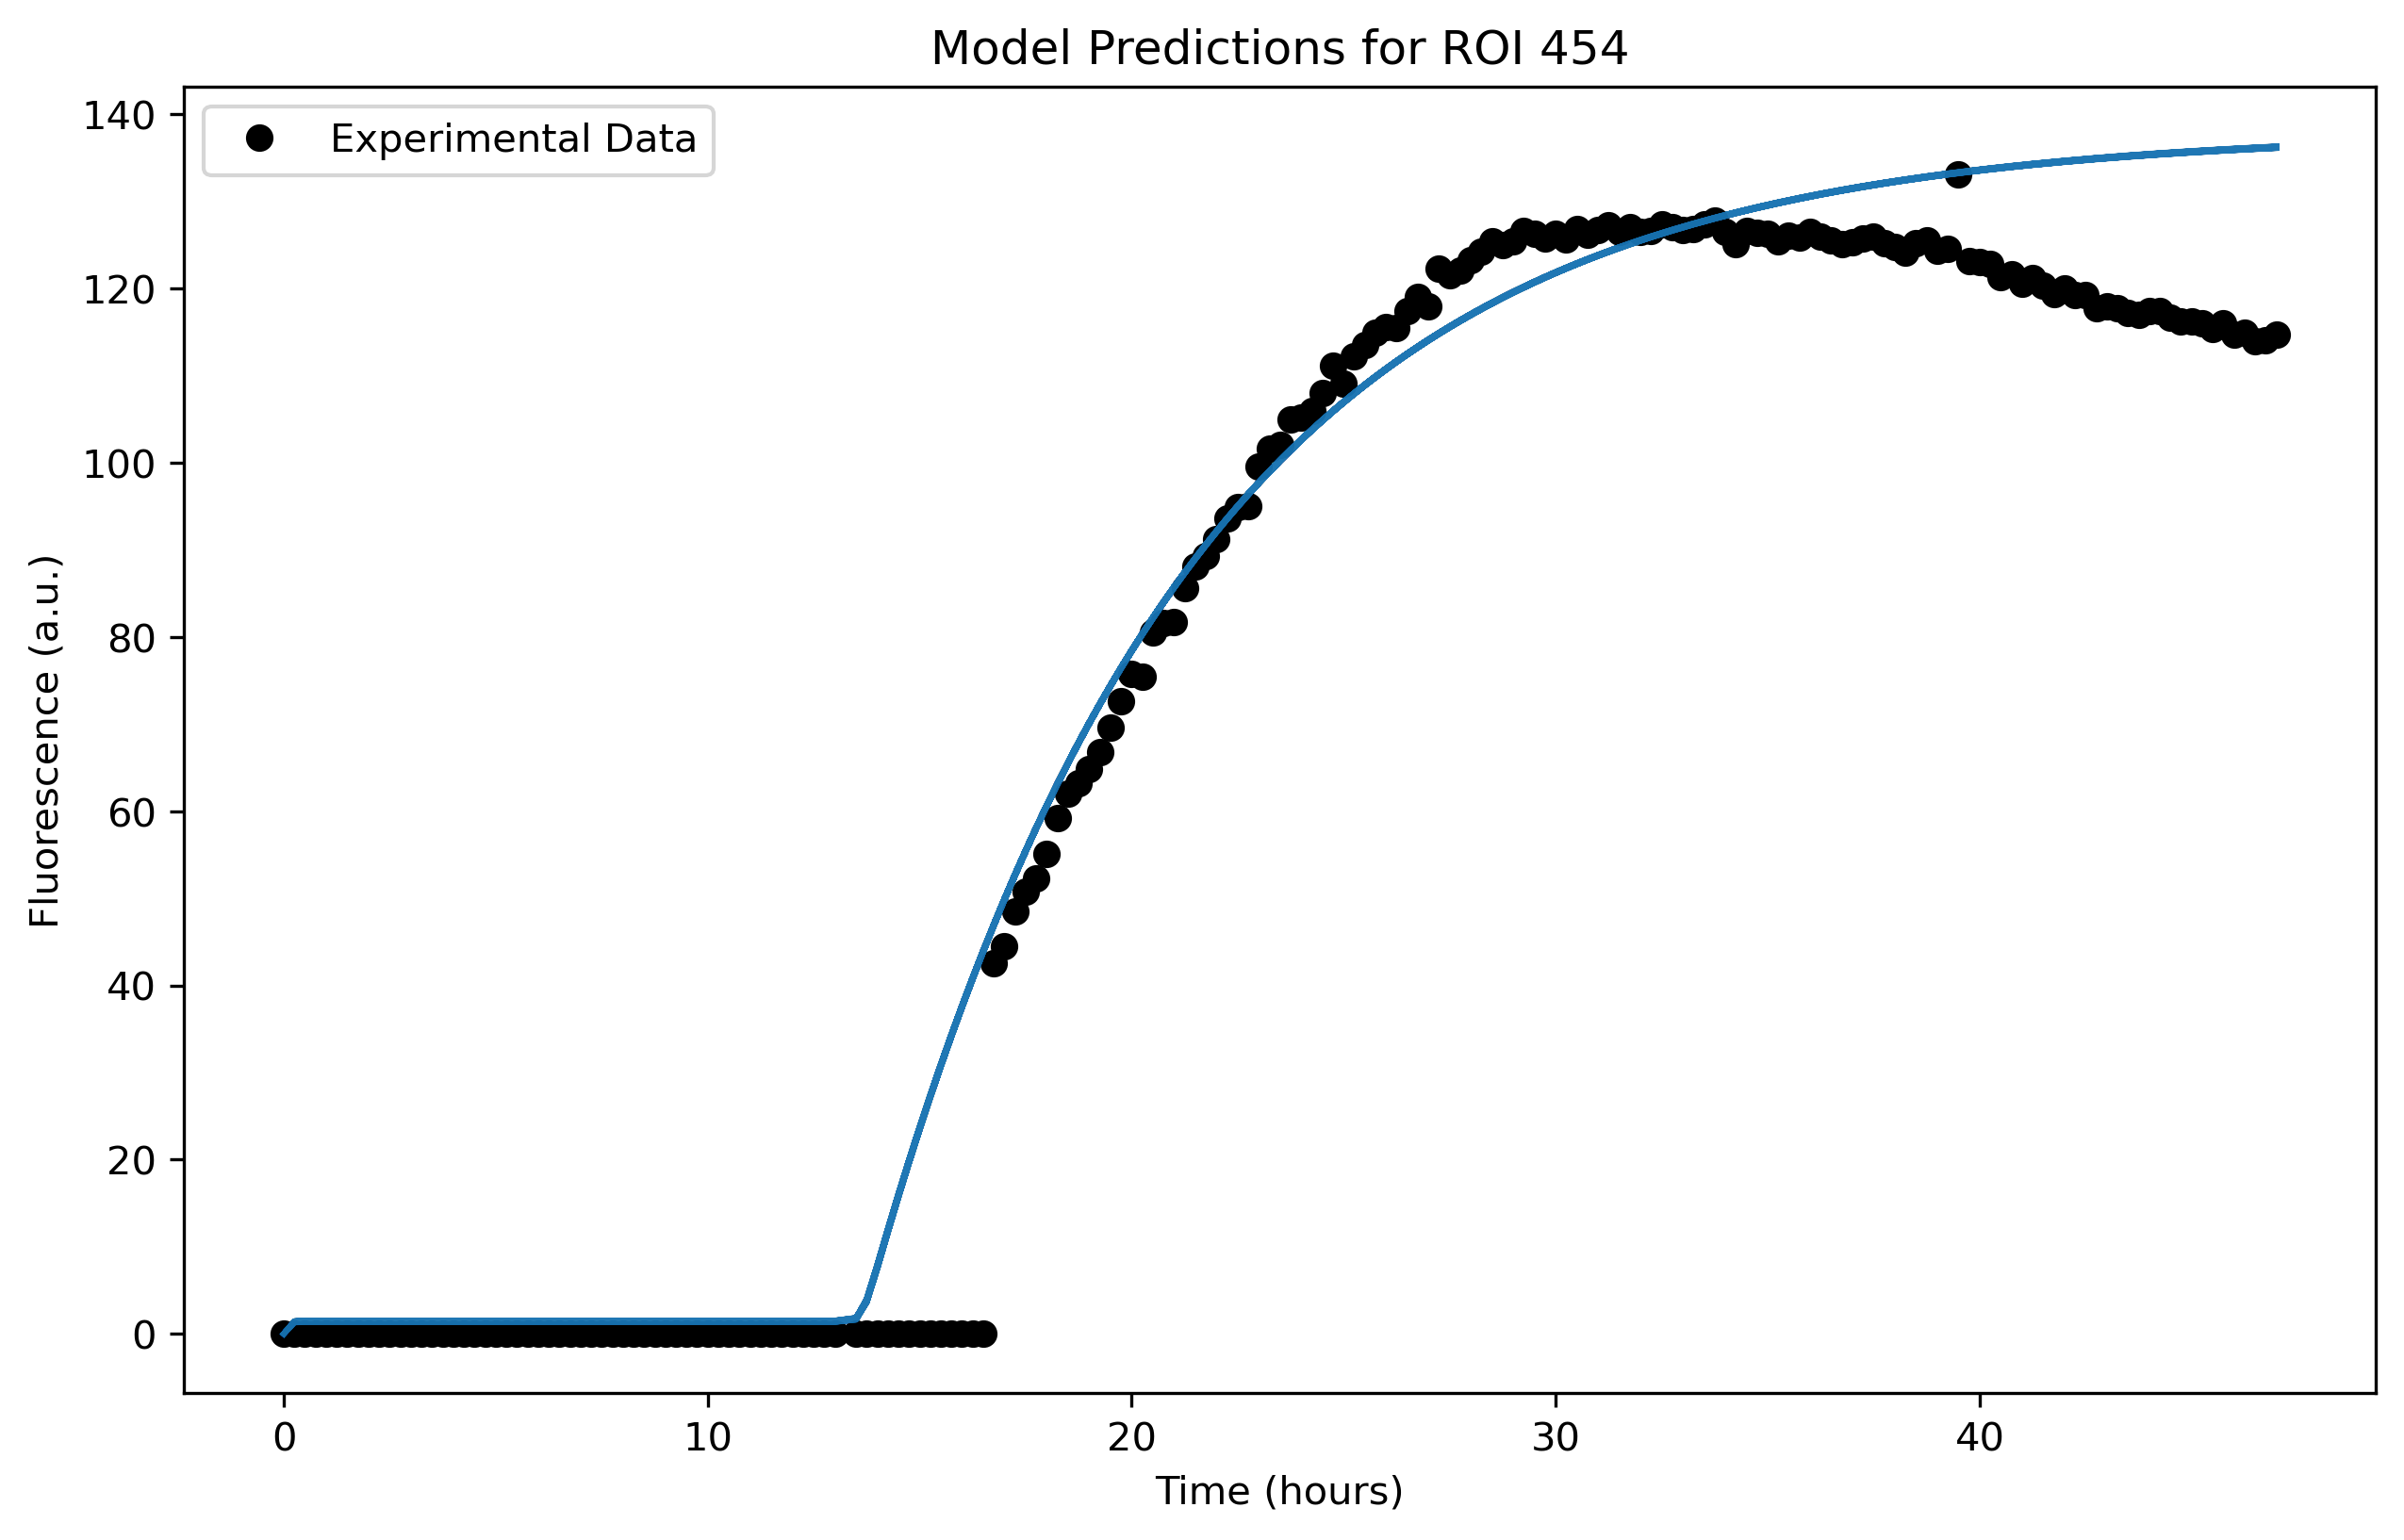

Plotting ROI 149: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1000/1000 [00:00<00:00, 1757.97it/s]


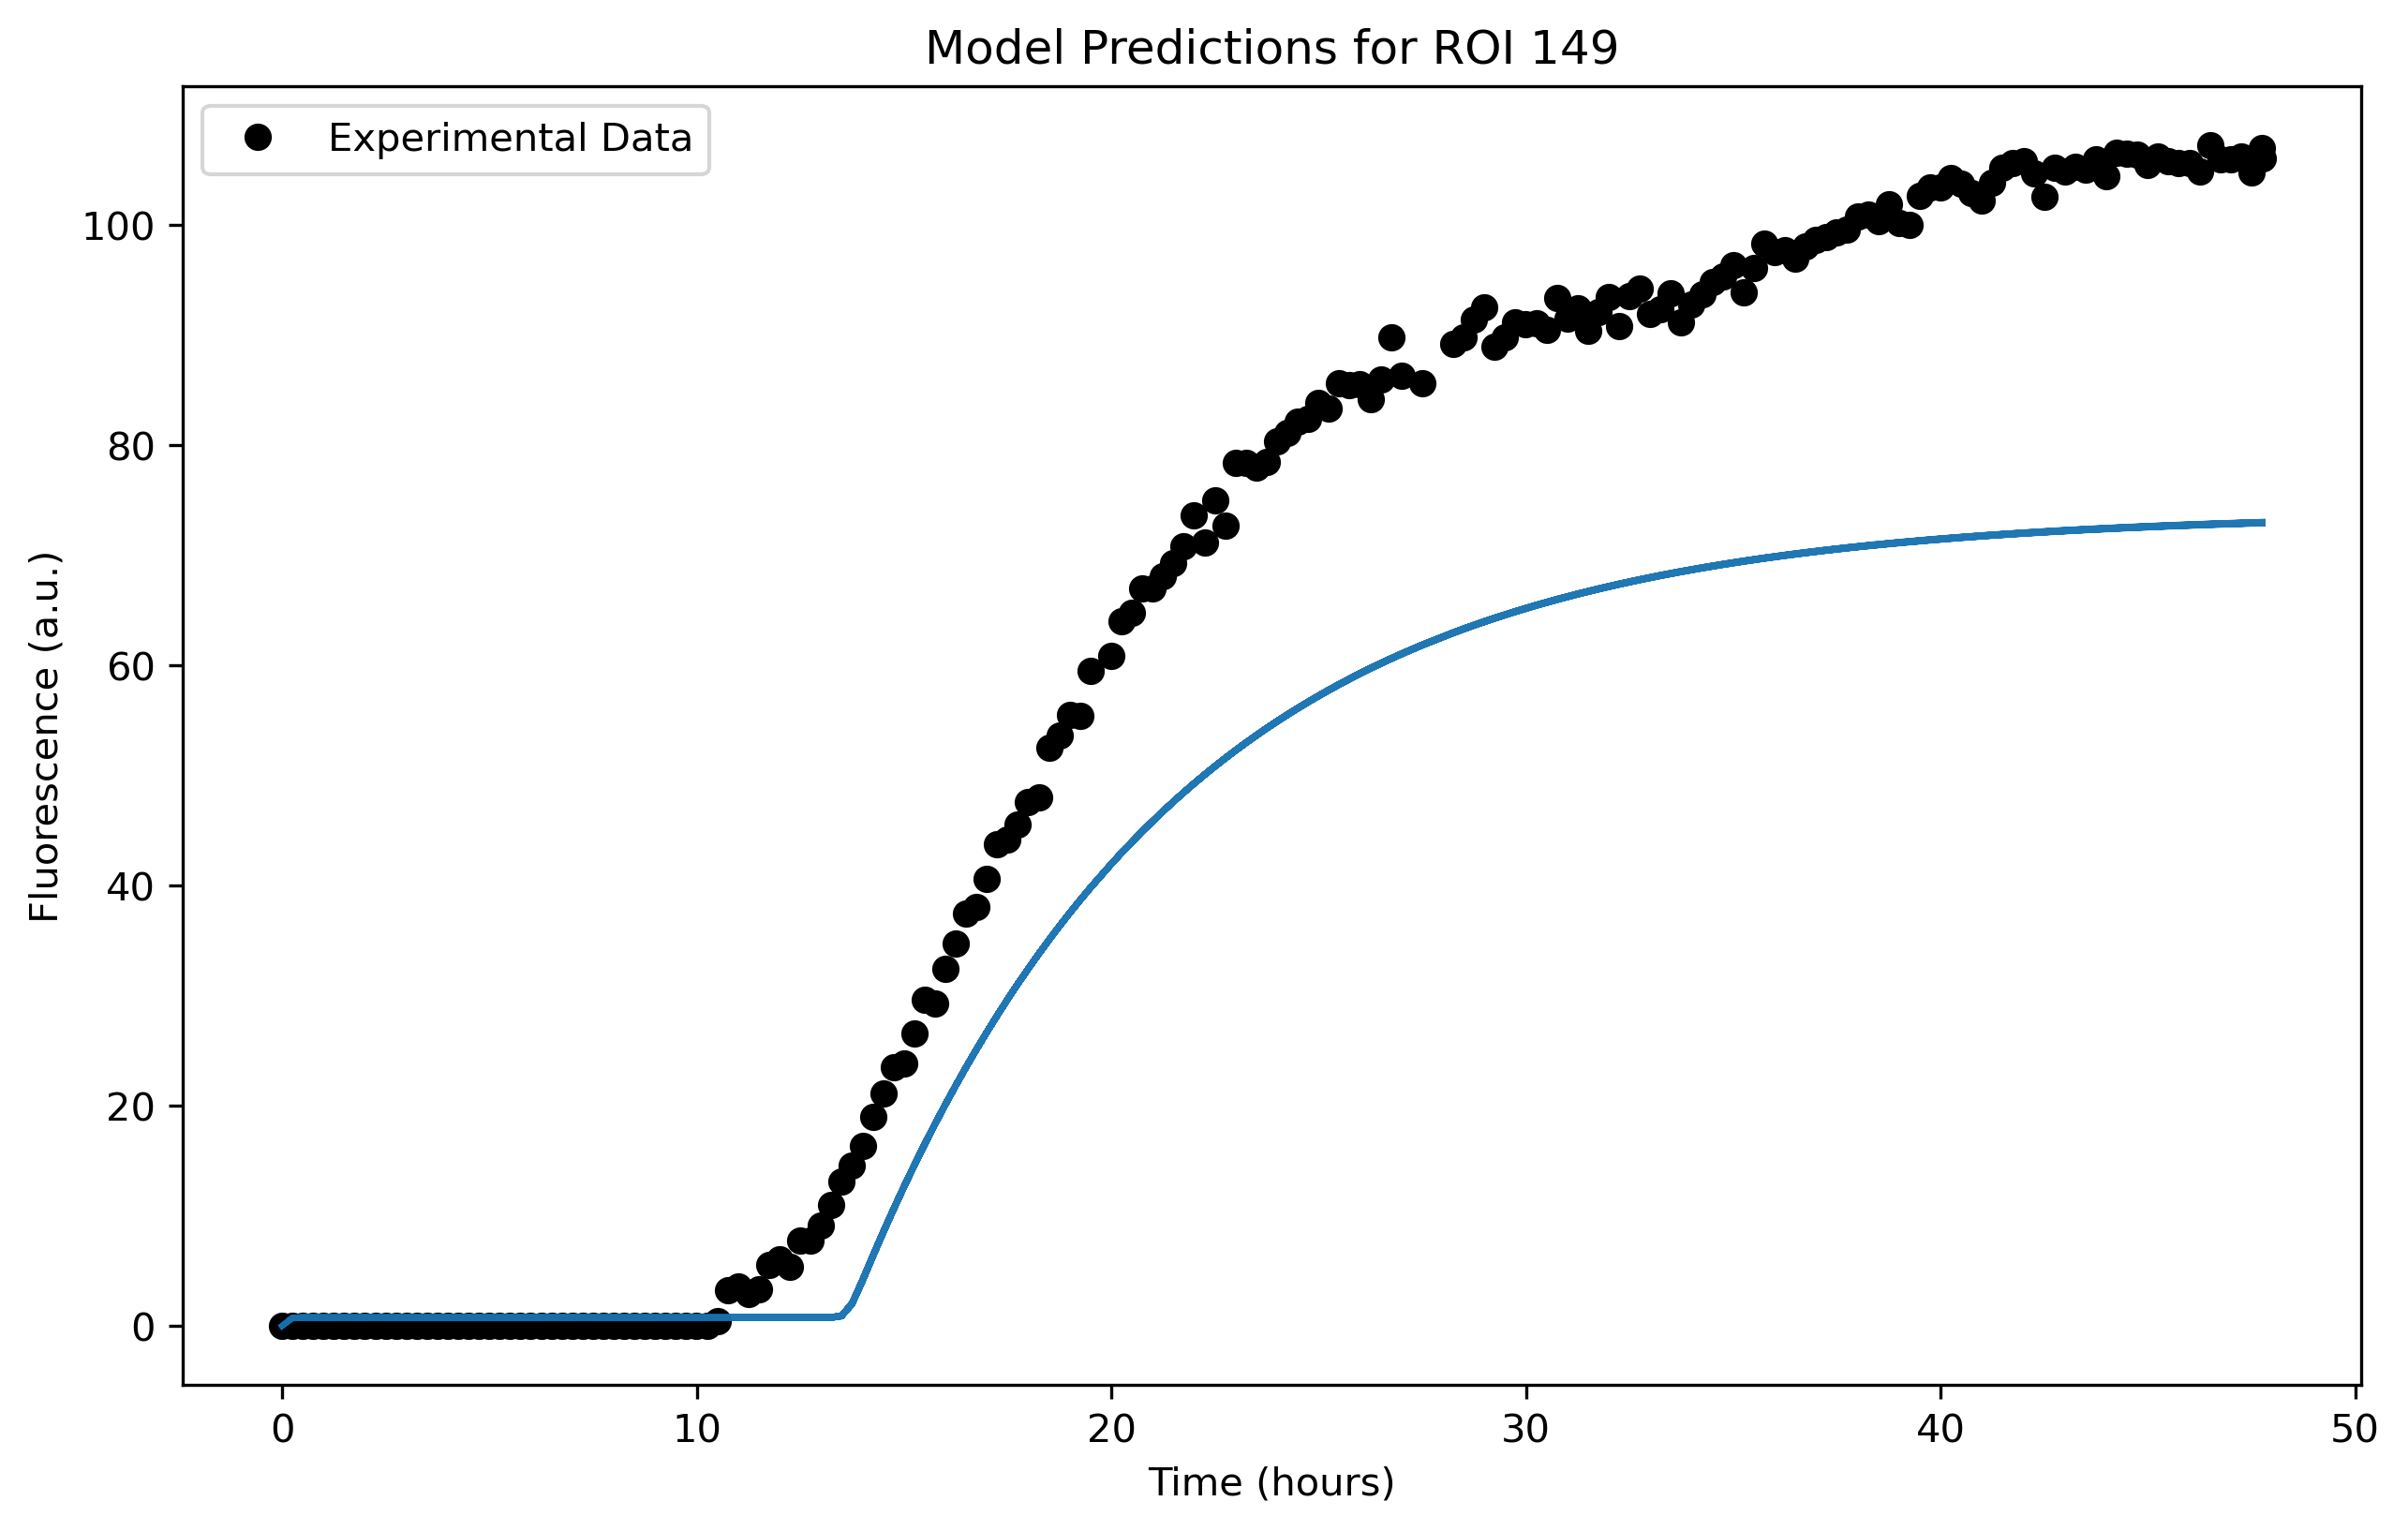

In [9]:
#base_path = "/Users/adaravena/Library/CloudStorage/GoogleDrive-adaravena94@gmail.com/My Drive/Optogenetics_JUN2025/fluopti_fits/"
base_path = r"G:\\My Drive\\Optogenetics_JUN2025\\fluopti_fits\\"
os.chdir(base_path)
print(f"Current directory: {os.getcwd()}")

data_analysis_dir = os.path.join(base_path, "data_analysis")
processed_dataset_dir = data_analysis_dir
df = pd.read_csv(os.path.join(processed_dataset_dir, "AGGREGATED_ROI_DATA.csv"))

big_dataset = List()
for col in tqdm.tqdm(df.columns[1:], desc="Pre-processing ROI data"):
    exp_id, _ = col.split("_")

    t_vec = parse_array_string(df.at[1, col])
    y_vec = parse_array_string(df.at[2, col])

    if len(t_vec) != len(np.unique(t_vec)):
        unique_indices = np.sort(np.unique(t_vec, return_index=True)[1])
        t_vec = t_vec[unique_indices]
        y_vec = y_vec[unique_indices]

    if t_vec.size < 2:
        continue

    t_vec = np.ascontiguousarray(t_vec)
    y_vec = np.ascontiguousarray(y_vec)

    I_G_vec, I_R_vec = lookup_light_schedule(exp_id, t_vec)
    u0 = np.array([y_vec[0]], np.float64)

    t_start = t_vec[0]
    time_step = t_vec[1] - t_vec[0]

    roi_data = ROIData(t_vec, y_vec, u0, I_G_vec, I_R_vec, t_start, time_step)
    big_dataset.append(roi_data)

print(f"Loaded and cached {len(big_dataset)} colony traces into Numba-ready format.")

num_rois_to_plot = 5
num_samples_to_plot = 1000

random_roi_indices = np.random.choice(len(big_dataset), num_rois_to_plot, replace=False)
random_sample_indices = np.random.choice(
    flat_samples_linear.shape[0], num_samples_to_plot, replace=False
)

funcptr = np.int64(funcptr_reduced.address)

for roi_idx in random_roi_indices:
    roi_data = big_dataset[roi_idx]

    plt.figure(figsize=(10, 6))
    plt.plot(roi_data.t, roi_data.y, "o", color="black", label="Experimental Data")

    for sample_idx in tqdm.tqdm(random_sample_indices, desc=f"Plotting ROI {roi_idx}"):
        theta_linear = flat_samples_linear[sample_idx]
        theta_lin = theta_linear[:-1]

        model_y = run_forward_model(theta_lin, roi_data, funcptr)
        plt.plot(roi_data.t, model_y, color="C0", alpha=0.1)

    plt.title(f"Model Predictions for ROI {roi_idx}")
    plt.xlabel("Time (hours)")
    plt.ylabel("Fluorescence (a.u.)")
    plt.legend()
    plt.savefig(f"ROI_{roi_idx}_model_predictions.png", dpi=300)
    plt.savefig(f"ROI_{roi_idx}_model_predictions.pdf")
    plt.show()
    plt.close()


## Configure unseen datasets
Define unseen experiment metadata and load them into ROIData objects for validation.

In [12]:
#UNSEEN_DATA_DIR = "/Users/adaravena/Library/CloudStorage/GoogleDrive-adaravena94@gmail.com/My Drive/Optogenetics_JUN2025/fluopti_fits/data_analysis/"
UNSEEN_DATA_DIR = r"G:\\My Drive\\Optogenetics_JUN2025\\fluopti_fits\\data_analysis\\"

NOT_TRAINED_TIMELAPSE_INFORMATION = {
    "TL240601": ["48HRS_RED_100PER", [0.00, 1.00]],
    "TL240526": ["48HRS_GREEN_60PER", [0.60, 0.00]],
}


def lookup_light_schedule_NOT_TRAINED(exp_id: str, t: np.ndarray):
    """Return green/red intensity vectors for an unseen experiment."""

    try:
        green_frac, red_frac = NOT_TRAINED_TIMELAPSE_INFORMATION[exp_id][1]
    except KeyError as exc:
        raise ValueError(f"Unknown experiment ID '{exp_id}'.") from exc
    I_G = np.full_like(t, green_frac, dtype=np.float64)
    I_R = np.full_like(t, red_frac, dtype=np.float64)
    return I_G, I_R


unseen_csv_files = [
    os.path.join(UNSEEN_DATA_DIR, f)
    for f in os.listdir(UNSEEN_DATA_DIR)
    if f.endswith(".csv")
    and "EXTRACTED_DATA" in f
    and any(key in f for key in NOT_TRAINED_TIMELAPSE_INFORMATION)
]

print(f"Found {len(unseen_csv_files)} unseen data files for validation.")

not_trained_big_dataset = List()
roi_experiment_ids = []

for csv_path in tqdm.tqdm(unseen_csv_files, desc="Loading unseen ROI data"):
    dataset_key = os.path.basename(csv_path).split("_")[-1].split(".")[0]

    if dataset_key not in NOT_TRAINED_TIMELAPSE_INFORMATION:
        print(
            f"Warning: Skipping {dataset_key} as it's not in NOT_TRAINED_TIMELAPSE_INFORMATION."
        )
        continue

    green_pct, red_pct = NOT_TRAINED_TIMELAPSE_INFORMATION[dataset_key][1]
    patched_df = load_and_patch_dataset(csv_path, green_pct, red_pct, max_rois=50)

    if patched_df is None:
        continue

    for col in patched_df.columns:
        t_vec = parse_array_string(patched_df.at["time", col])
        y_vec = parse_array_string(patched_df.at["exp_data_means", col])

        if t_vec.size < 2:
            continue

        I_G_vec, I_R_vec = lookup_light_schedule_NOT_TRAINED(dataset_key, t_vec)
        u0 = np.array([y_vec[0]], dtype=np.float64)
        t_start = t_vec[0]
        time_step = t_vec[1] - t_vec[0]

        roi_data = ROIData(t_vec, y_vec, u0, I_G_vec, I_R_vec, t_start, time_step)
        not_trained_big_dataset.append(roi_data)
        roi_experiment_ids.append(dataset_key)

print(
    f"Loaded and processed {len(not_trained_big_dataset)} unseen colony traces into Numba-ready format."
)

grouped_datasets = defaultdict(list)
for i, roi_data in enumerate(not_trained_big_dataset):
    dataset_id = roi_experiment_ids[i]
    grouped_datasets[dataset_id].append(roi_data)

print(
    f"Grouped unseen data into {len(grouped_datasets)} distinct datasets: {list(grouped_datasets.keys())}"
)


POTENTIAL_PROCESSED_DATASET_DIRS = [
    r"E:\datos crudos\all_data\data",  # Windows external drive path
    "/Volumes/datos crudos/all_data/data",     # macOS external volume path
]
PROCESSED_DATASET_DIR = next(
    (p for p in POTENTIAL_PROCESSED_DATASET_DIRS if os.path.isdir(p)),
    POTENTIAL_PROCESSED_DATASET_DIRS[0],
)
print("Processed dataset dir candidates:", POTENTIAL_PROCESSED_DATASET_DIRS)
if not os.path.isdir(PROCESSED_DATASET_DIR):
    print(
        "WARNING: None of the processed dataset directories exist locally. "
        "Set PROCESSED_DATASET_DIR manually if your drive is mounted differently."
    )


Found 4 unseen data files for validation.


Loading unseen ROI data: 100%|██████████| 4/4 [00:01<00:00,  3.14it/s]


Loaded and processed 150 unseen colony traces into Numba-ready format.
Grouped unseen data into 2 distinct datasets: ['TL240601', 'TL240526']
Processed dataset dir candidates: ['E:\\datos crudos\\all_data\\data', '/Volumes/datos crudos/all_data/data']


## Posterior predictive check on unseen data
Compare posterior simulations against unseen experiments, plotting MAP and 95% intervals.

In [ ]:
if grouped_datasets:
    n_posterior_samples = 20_000
    n_plot_samples = 1_000

    fig, ax = plt.subplots(figsize=set_size("thesis", fraction=1.5))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(grouped_datasets)))
    funcptr = np.int64(funcptr_reduced.address)

    map_theta_lin = np.median(flat_samples_linear[:, :-1], axis=0)

    for i, (dataset_id, records) in enumerate(grouped_datasets.items()):
        print(
            f"\n--- Processing dataset for plotting: {NOT_TRAINED_TIMELAPSE_INFORMATION[dataset_id][0]} ({len(records)} ROIs) ---"
        )
        color = colors[i]

        max_time = max(roi.t[-1] for roi in records if roi.t.size > 0)
        common_t = np.linspace(0, max_time, 1000)

        interpolated_ys = np.array(
            [np.interp(common_t, roi.t, roi.y) for roi in records if roi.t.size > 1]
        )
        if interpolated_ys.shape[0] < 2:
            print(
                f"Skipping {NOT_TRAINED_TIMELAPSE_INFORMATION[dataset_id][0]}, not enough valid ROIs for statistics."
            )
            continue

        mean_exp_y = np.mean(interpolated_ys, axis=0)
        std_exp_y = np.std(interpolated_ys, axis=0)
        ax.plot(
            common_t,
            mean_exp_y,
            color=color,
            lw=2,
            label=f"Mean Data ({NOT_TRAINED_TIMELAPSE_INFORMATION[dataset_id][0]})",
        )
        ax.fill_between(
            common_t,
            mean_exp_y - std_exp_y,
            mean_exp_y + std_exp_y,
            color=color,
            alpha=0.15,
        )

        mean_u0 = np.array([np.mean([rec.u0[0] for rec in records])], dtype=np.float64)
        I_G_common, I_R_common = lookup_light_schedule_NOT_TRAINED(dataset_id, common_t)
        sim_roi_data = ROIData(
            common_t,
            np.array([]),
            mean_u0,
            I_G_common,
            I_R_common,
            common_t[0],
            common_t[1] - common_t[0],
        )

        sample_indices = np.random.choice(
            flat_samples_linear.shape[0], n_posterior_samples, replace=False
        )
        posterior_thetas = flat_samples_linear[sample_indices, :-1]

        posterior_sims = np.array(
            [
                run_forward_model(theta, sim_roi_data, funcptr)
                for theta in tqdm.tqdm(
                    posterior_thetas,
                    desc=f"Simulating for {NOT_TRAINED_TIMELAPSE_INFORMATION[dataset_id][0]}",
                )
            ]
        )

        lower_ci, median_pred, upper_ci = np.percentile(
            posterior_sims, [2.5, 50, 97.5], axis=0
        )
        map_trajectory = run_forward_model(map_theta_lin, sim_roi_data, funcptr)

        ax.plot(
            common_t,
            map_trajectory,
            color=color,
            ls="--",
            lw=2,
            label=f"MAP Pred. ({NOT_TRAINED_TIMELAPSE_INFORMATION[dataset_id][0]})",
        )
        ax.fill_between(
            common_t,
            lower_ci,
            upper_ci,
            color=color,
            alpha=0.2,
            label=f"95% CI ({dataset_id})",
        )

    ax.set_xlabel("Time (h)", fontsize=12)
    ax.set_ylabel("Fluorescence (a.u.)", fontsize=12)
    ax.set_title("Posterior Predictive Check on Unseen Data", fontsize=14)
    ax.legend(loc="upper left", frameon=False, fontsize=8)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    fig.savefig("posterior_predictive_check_combined_03112025_FINAL.png", dpi=300)
    fig.savefig("posterior_predictive_check_combined_03112025_FINAL.pdf")
    print(
        "\nPosterior predictive check plot saved as 'posterior_predictive_check_combined_03112025_FINAL.png'"
    )
    plt.show()


## Prior vs posterior comparison
Plot prior density against posterior samples in log and linear space.

In [34]:
lower_bound_reduced = np.array([1e-6, 1e-2, 1e-3, 10.0, 1e-3, 1e-3, 1e-3, 1e-3])
upper_bound_reduced = np.array([2.5e1, 1e0, 1e3, 20.0, 1e3, 1e3, 1e3, 1e3])
data_reduced_guess = np.array(
    [1.25, 0.06, 1.0, 13.0, 40.0, 0.588235294, 0.0882352941, 0.02012]
)
n_params = len(lower_bound_reduced)
ndim = n_params + 1
nwalkers = 32 * ndim
nsteps = 50_000
lower_log = np.append(np.log10(lower_bound_reduced), np.log10(1.0))
upper_log = np.append(np.log10(upper_bound_reduced), np.log10(10.0))
prior_modes = np.array([PRIOR_UNIFORM] * n_params + [PRIOR_UNIFORM])
mu_log_reduced = np.append(np.log10(data_reduced_guess), np.log10(5.0))
sigmas_log = np.array([1.96] * n_params + [1.96])


In [35]:
LN10 = np.log(10.0)

def _prior_pdf_on_grid_log(grid, lo, hi, mode, mu, sig):
    pdf = np.zeros_like(grid)
    in_support = (grid >= lo) & (grid <= hi)

    if mode == PRIOR_UNIFORM:
        pdf[in_support] = 1.0
    elif mode == PRIOR_GAUSS:
        z = (grid - mu) / (sig if sig > 0 else 1e-12)
        pdf[in_support] = np.exp(-0.5 * z**2)
    else:
        pdf[in_support] = 1.0

    area = np.trapz(pdf, grid)
    if area > 0:
        pdf /= area
    return pdf


def _hist_density(x, bins):
    counts, edges = np.histogram(x, bins=bins, density=False)
    width = np.diff(edges)
    n = x.size
    density = counts.astype(np.float64) / (n * width)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, density, width.mean()


def _smooth_gaussian(y, bin_width, std_sample, n_samples, rule="scott"):
    if std_sample <= 0 or n_samples <= 1:
        return y

    bw = (
        std_sample * (n_samples ** (-1 / 5.0))
        if rule == "scott"
        else std_sample * (n_samples ** (-1 / 5.0))
    )
    sigma_bins = max(bw / max(bin_width, 1e-12), 1e-3)

    half_w = int(np.ceil(3.0 * sigma_bins))
    kx = np.arange(-half_w, half_w + 1, dtype=np.float64)
    kernel = np.exp(-0.5 * (kx / sigma_bins) ** 2)
    kernel /= kernel.sum()

    return np.convolve(y, kernel, mode="same")


def _maybe_make_dir(path):
    if path and not os.path.isdir(path):
        os.makedirs(path, exist_ok=True)


def prior_posterior_1d_fast(
    flat_samples_log: np.ndarray,
    labels_log,
    lower_log: np.ndarray,
    upper_log: np.ndarray,
    prior_modes: np.ndarray,
    mu_log: np.ndarray,
    sig_log: np.ndarray,
    *,
    space: str = "log",
    bins: int = 256,
    smooth: bool = True,
    save_dir: str | None = None,
    show: bool = False,
):
    assert space in ("log", "linear")
    _maybe_make_dir(save_dir)

    results = []
    D = flat_samples_log.shape[1]

    flat_samples_linear = None
    if space == "linear":
        flat_samples_linear = 10.0**flat_samples_log

    for j in range(D):
        if space == "log":
            data = flat_samples_log[:, j]
            lo, hi = lower_log[j], upper_log[j]
            x_min = min(data.min(), lo)
            x_max = max(data.max(), hi)
            x_label = labels_log[j]
        else:
            data = flat_samples_linear[:, j]
            lo, hi = lower_log[j], upper_log[j]
            post_log_min = np.log10(np.maximum(data.min(), 1e-300))
            post_log_max = np.log10(np.maximum(data.max(), 1e-300))
            lo_eff = min(lo, post_log_min)
            hi_eff = max(hi, post_log_max)
            x_label = labels_log[j].replace("log10(", "").replace(")", "")

        centers, dens, bin_w = _hist_density(data, bins=bins)

        if smooth:
            std_sample = np.std(data)
            dens_s = _smooth_gaussian(dens, bin_w, std_sample, data.size)
        else:
            dens_s = dens

        if space == "log":
            grid = np.linspace(x_min, x_max, 1024, dtype=np.float64)
            pdf_prior = _prior_pdf_on_grid_log(
                grid, lo, hi, prior_modes[j], mu_log[j], sig_log[j]
            )
            grid_x = grid
            prior_y = pdf_prior
        else:
            grid_log = np.linspace(lo_eff, hi_eff, 2048, dtype=np.float64)
            pdf_log = _prior_pdf_on_grid_log(
                grid_log, lo, hi, prior_modes[j], mu_log[j], sig_log[j]
            )
            grid_x = 10.0**grid_log
            prior_y = pdf_log / (grid_x * LN10)
            area = np.trapz(prior_y, grid_x)
            if area > 0:
                prior_y /= area

        fig, ax = plt.subplots(figsize=(6, 3.5))
        ax.step(centers, dens_s, where="mid", linewidth=1.0, label="Posterior")
        ax.plot(grid_x, prior_y, linewidth=1.2, linestyle="-", label="Prior")

        ax.set_xlabel(x_label)
        ax.set_ylabel("Density")
        ax.legend(frameon=False)
        ax.grid(alpha=0.25, linewidth=0.5)

        outfile = None
        if save_dir is not None:
            safe = x_label.replace("/", "_").replace(" ", "_")
            outfile = os.path.join(
                save_dir, f"prior_vs_posterior_{space}_{j:02d}_{safe}_13112025.png"
            )
            fig.savefig(outfile, bbox_inches="tight", dpi=300)
            plt.close(fig)
        elif show:
            plt.show()
        else:
            plt.close(fig)

        results.append((x_label, outfile))

    return results


param_labels_log = [
    f"log10({name})"
    for name in ["a1", "d_p", "mu_max", "t_half", "a3", "a4", "a5", "a6", "sigma"]
]

prior_posterior_1d_fast(
    flat_samples_log=flat_samples_log,
    labels_log=param_labels_log,
    lower_log=lower_log,
    upper_log=upper_log,
    prior_modes=prior_modes,
    mu_log=mu_log_reduced,
    sig_log=sigmas_log,
    space="log",
    save_dir="",
    show=False,
)

prior_posterior_1d_fast(
    flat_samples_log=flat_samples_log,
    labels_log=[f"log10({n})" for n in param_labels_linear],
    lower_log=lower_log,
    upper_log=upper_log,
    prior_modes=prior_modes,
    mu_log=mu_log_reduced,
    sig_log=sigmas_log,
    space="linear",
    save_dir="",
    show=False,
)


[('a1', 'prior_vs_posterior_linear_00_a1_13112025.png'),
 ('d_p', 'prior_vs_posterior_linear_01_d_p_13112025.png'),
 ('mu_max', 'prior_vs_posterior_linear_02_mu_max_13112025.png'),
 ('t_half', 'prior_vs_posterior_linear_03_t_half_13112025.png'),
 ('a3', 'prior_vs_posterior_linear_04_a3_13112025.png'),
 ('a4', 'prior_vs_posterior_linear_05_a4_13112025.png'),
 ('a5', 'prior_vs_posterior_linear_06_a5_13112025.png'),
 ('a6', 'prior_vs_posterior_linear_07_a6_13112025.png'),
 ('sigma', 'prior_vs_posterior_linear_08_sigma_13112025.png')]

## R² metrics and dataset diagnostics
Posterior predictive R² variants and quick diagnostics for low-performing datasets.

In [36]:
def compute_r2_bayesian(
    grouped_datasets, flat_samples_linear, funcptr, N_SAMPLES=1000, seed=42
):
    rng = np.random.default_rng(seed)

    idx = rng.choice(flat_samples_linear.shape[0], size=N_SAMPLES, replace=False)
    thetas = flat_samples_linear[idx, :-1]
    sigmas = flat_samples_linear[idx, -1]

    all_y = []
    all_y_pred_mean = []
    all_y_pred_var = []
    all_residuals = []

    r2_per_dataset = {}

    for dataset_id, records in grouped_datasets.items():
        dataset_y = []
        dataset_pred_mean = []

        for roi in records:
            t = roi.t
            y = roi.y

            preds = np.empty((N_SAMPLES, t.size), dtype=np.float64)
            valid_count = 0

            for s in range(N_SAMPLES):
                pred = run_forward_model(thetas[s], roi, np.int64(funcptr))
                if np.all(np.isfinite(pred)):
                    preds[valid_count] = pred
                    valid_count += 1

            if valid_count < 10:
                continue

            preds = preds[:valid_count]

            pred_mean = np.mean(preds, axis=0)
            pred_var = np.var(preds, axis=0)

            all_y.extend(y)
            all_y_pred_mean.extend(pred_mean)
            all_y_pred_var.extend(pred_var)
            all_residuals.extend(y - pred_mean)

            dataset_y.extend(y)
            dataset_pred_mean.extend(pred_mean)

        if len(dataset_y) > 1:
            dataset_y = np.array(dataset_y)
            dataset_pred_mean = np.array(dataset_pred_mean)
            ss_res = np.sum((dataset_y - dataset_pred_mean) ** 2)
            ss_tot = np.sum((dataset_y - np.mean(dataset_y)) ** 2)
            r2_per_dataset[dataset_id] = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    all_y = np.array(all_y)
    all_y_pred_mean = np.array(all_y_pred_mean)
    all_y_pred_var = np.array(all_y_pred_var)
    all_residuals = np.array(all_residuals)

    ss_res = np.sum(all_residuals**2)
    ss_tot = np.sum((all_y - np.mean(all_y)) ** 2)
    r2_classical = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    var_pred = np.var(all_y_pred_mean)
    var_resid = np.var(all_residuals)
    r2_bayesian = (
        var_pred / (var_pred + var_resid) if (var_pred + var_resid) > 0 else np.nan
    )

    mean_sigma2 = np.mean(sigmas**2)
    mean_pred_var = np.mean(all_y_pred_var)
    total_pred_var = mean_pred_var + mean_sigma2
    r2_predictive = (
        var_pred / (var_pred + total_pred_var)
        if (var_pred + total_pred_var) > 0
        else np.nan
    )

    return {
        "r2_classical": r2_classical,
        "r2_bayesian": r2_bayesian,
        "r2_predictive": r2_predictive,
        "r2_per_dataset": r2_per_dataset,
        "n_observations": len(all_y),
        "rmse": np.sqrt(ss_res / len(all_y)) if len(all_y) > 0 else np.nan,
    }


def compute_r2_with_credible_interval(
    grouped_datasets,
    flat_samples_linear,
    funcptr,
    N_BOOTSTRAP=100,
    N_SAMPLES_PER_BOOT=500,
    seed=42,
):
    rng = np.random.default_rng(seed)

    r2_samples = []

    for _ in range(N_BOOTSTRAP):
        idx = rng.choice(
            flat_samples_linear.shape[0], size=N_SAMPLES_PER_BOOT, replace=True
        )
        thetas = flat_samples_linear[idx, :-1]

        all_y = []
        all_pred_mean = []

        for dataset_id, records in grouped_datasets.items():
            for roi in records:
                t = roi.t
                y = roi.y

                preds = []
                for s in range(min(50, N_SAMPLES_PER_BOOT)):
                    pred = run_forward_model(thetas[s], roi, np.int64(funcptr))
                    if np.all(np.isfinite(pred)):
                        preds.append(pred)

                if len(preds) < 5:
                    continue

                pred_mean = np.mean(preds, axis=0)
                all_y.extend(y)
                all_pred_mean.extend(pred_mean)

        if len(all_y) > 1:
            all_y = np.array(all_y)
            all_pred_mean = np.array(all_pred_mean)
            ss_res = np.sum((all_y - all_pred_mean) ** 2)
            ss_tot = np.sum((all_y - np.mean(all_y)) ** 2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
            if np.isfinite(r2):
                r2_samples.append(r2)

    r2_samples = np.array(r2_samples)

    return {
        "r2_median": np.median(r2_samples),
        "r2_mean": np.mean(r2_samples),
        "r2_ci_lower": np.percentile(r2_samples, 2.5),
        "r2_ci_upper": np.percentile(r2_samples, 97.5),
        "r2_std": np.std(r2_samples),
        "n_bootstrap": len(r2_samples),
    }


funcptr_r2 = np.int64(funcptr_reduced.address)

In [ ]:
print("Computing R² metrics...")
r2_results = compute_r2_bayesian(
    grouped_datasets, flat_samples_linear, funcptr_r2, N_SAMPLES=2000, seed=42
)

print("\n" + "=" * 60)
print("R² RESULTS FOR PUBLICATION")
print("=" * 60)
print(f"\n1. Classical R² (posterior mean):     {r2_results['r2_classical']:.4f}")
print(f"2. Bayesian R² (Gelman et al. 2019):  {r2_results['r2_bayesian']:.4f}")
print(f"3. Posterior Predictive R²:           {r2_results['r2_predictive']:.4f}")
print(f"\nRMSE: {r2_results['rmse']:.4f}")
print(f"N observations: {r2_results['n_observations']}")

print("\n--- Per-Dataset R² ---")
for dsid, r2 in r2_results["r2_per_dataset"].items():
    print(f"  {dsid}: {r2:.4f}")

print("\nComputing R² with credible interval (bootstrap)...")
r2_ci = compute_r2_with_credible_interval(
    grouped_datasets,
    flat_samples_linear,
    funcptr_r2,
    N_BOOTSTRAP=100,
    N_SAMPLES_PER_BOOT=500,
    seed=42,
)

print(
    f"\nR² = {r2_ci['r2_median']:.4f} [{r2_ci['r2_ci_lower']:.4f}, {r2_ci['r2_ci_upper']:.4f}] (95% CI)"
)


In [ ]:
dataset_id = "TL240601"
records = grouped_datasets[dataset_id]

all_y = np.concatenate([roi.y for roi in records])
print(f"Dataset: {dataset_id}")
print(f"  N observations: {len(all_y)}")
print(f"  y range: [{all_y.min():.2f}, {all_y.max():.2f}]")
print(f"  y mean: {all_y.mean():.2f}")
print(f"  y std: {all_y.std():.2f}")
print(f"  Coefficient of variation: {all_y.std() / all_y.mean():.2%}")

funcptr = np.int64(funcptr_reduced.address)
map_theta_lin = np.median(flat_samples_linear[:, :-1], axis=0)

all_y_obs = []
all_y_pred = []

for roi in records:
    pred = run_forward_model(map_theta_lin, roi, funcptr)
    if np.all(np.isfinite(pred)):
        all_y_obs.extend(roi.y)
        all_y_pred.extend(pred)

all_y_obs = np.array(all_y_obs)
all_y_pred = np.array(all_y_pred)

cv = all_y_obs.std() / all_y_obs.mean()
correlation = np.corrcoef(all_y_obs, all_y_pred)[0, 1]
mean_bias = np.mean(all_y_pred - all_y_obs)

print(f"CV: {cv:.2%}")
print(f"Correlation (obs vs pred): {correlation:.3f}")
print(f"Mean bias (pred - obs): {mean_bias:.2f}")


## Changing optogenetic regime (0-24h G -> 24-48h R -> 48-72h G)
Use the piecewise light schedule to compare the model with a 72 h dataset (colony mean and per-ROI).


In [22]:
def exportRoisData(rois, dataset, width=1, offset=0, save_dir=None, dataset_name=None):

    """
    This function will export all the data from the ROIs in the dataset to a CSV file. Specifically, will parse the
    experimental data, the time vector, the initial conditions, and the control schedule. With this, it will fill out a dictionary
    and will export it to a CSV file and also will save the variable as a dataframe.

    Parameters
    ----------
    rois : list
        List of ROIs from the dataset.
    dataset : fluopi.dataset.Dataset
        Dataset object from the fluopti module. Has various data from the timelapse experiments.
    save_dir : str, optional
        Directory where the CSV will be written. Defaults to the data_analysis folder under the working/base path.
    dataset_name : str, optional
        Custom name for the exported CSV.

    Returns
    -------
    data_df : pandas.DataFrame
        Dataframe with the experimental data, time vector, initial conditions, and control schedule for each ROI. ROI entries are
        STRING type.
    """
    
    # Create a dictionary to store the data
    data_dict = {}

    # Loop over the ROIs
    for roi_index, roi in enumerate(rois):
        
        # Extract the experimental timepoints from the dataset
        tpoints = rois[roi].times['W']
        # Wait 1 second
        time.sleep(1)
        # Extract the experimental data from the dataset
        experimental_data_means, experimental_data_std = flua.border_signal(rois[roi], wide=width, offset=offset)
        # Convert the NaN values to 0
        experimental_data_means = np.nan_to_num(experimental_data_means)
        experimental_data_std = np.nan_to_num(experimental_data_std)

        # Define the initial and final time points for the ODE solver
        t0_tf = [tpoints[0], tpoints[-1]]
        # Convert to numpy array
        t0_tf = np.array(t0_tf)
        # Define the time points to save the results
        data_tpoints = np.linspace(tpoints[0], tpoints[-1], len(tpoints))
        # Define the initial condition for the ODE
        IA_0 = [experimental_data_means[0]]
        # Convert to numpy array
        IA_0 = np.array(IA_0)

        # Optogenetic control schedule (obtain from the dataset)
        schedule_times = dataset.control_regime['T']
        schedule_R = [int(i/100) for i in dataset.control_regime['R']]
        schedule_G = [int(i/100) for i in dataset.control_regime['G']]
        # Convert to numpy arrays
        schedule_times = np.array(schedule_times)
        # For the schedule_R and schedule_G, we need to compare against the timepoints and decide the value (0 or 1)
        schedule_R = np.array(schedule_R)
        schedule_G = np.array(schedule_G)
        schedule_R_times = np.zeros(len(data_tpoints), dtype=np.float64)
        schedule_G_times = np.zeros(len(data_tpoints), dtype=np.float64)

        for i, timepoint in enumerate(data_tpoints):
            step = next((i for i, time_limit in enumerate(schedule_times) if timepoint < time_limit), len(schedule_times)-1)
            schedule_R_times[i] = schedule_R[step]
            schedule_G_times[i] = schedule_G[step]

        # Wait 1 second
        time.sleep(1)
        # Store the data in the dictionary
        # Make a string for the ROI_index
        roi_index = str(roi_index)
        data_dict[roi_index] = {'roi': int(roi_index), 
                                'time': tpoints, 
                                'exp_data_means': experimental_data_means, 
                                'exp_data_stds': experimental_data_std,
                                't0_tf': t0_tf,
                                'data_tpoints': data_tpoints,
                                'IA_0': IA_0,
                                'schedule_times': schedule_times,
                                'schedule_R': schedule_R,
                                'schedule_G': schedule_G,
                                'schedule_R_COMPLETE': schedule_R_times,
                                'schedule_G_COMPLETE': schedule_G_times,
                                'firstswitch': np.array([schedule_times[0]]*len(tpoints), dtype=np.float64),
                                'secondswitch': np.array([schedule_times[1]]*len(tpoints), dtype=np.float64)}

    # Convert the data to dataframe
    data_df = pd.DataFrame(data_dict)

    # Decide where to save and what to name the export
    default_base = working_path if 'working_path' in globals() else base_path if 'base_path' in globals() else os.getcwd()
    target_dir = save_dir if save_dir is not None else os.path.join(default_base, 'data_analysis')
    os.makedirs(target_dir, exist_ok=True)

    label = str(dataset_name) if dataset_name is not None else (true_name if 'true_name' in globals() else getattr(dataset, 'name', 'dataset'))
    output_path = os.path.join(target_dir, f'EXTRACTED_DATA_{label}.csv')
    data_df.to_csv(output_path, index=False)
    print(f'Saved ROI export to: {output_path}')

    # Return the data dict
    return data_df


In [23]:
from fluopi import analysis
from fluopi import plotting

In [24]:
PICKLE_PATH = r"E:\datos crudos\all_data\data"

In [40]:
# Configure the piecewise light schedule dataset
CHANGING_REGIME_ID = "TL240224"

CHANGING_REGIME_PICKLE_DIR = PICKLE_PATH
CHANGING_REGIME_PICKLE_NAME = f"MAY2025_UPDATED_DATA_{CHANGING_REGIME_ID}.pickle"
CHANGING_REGIME_PICKLE_PATH = os.path.join(CHANGING_REGIME_PICKLE_DIR, CHANGING_REGIME_PICKLE_NAME)
CHANGING_REGIME_EXPORT_DIR = UNSEEN_DATA_DIR
FORCE_EXPORT_CHANGING_REGIME = True

csv_candidates = [
    os.path.join(CHANGING_REGIME_EXPORT_DIR, f"EXTRACTED_DATA_{CHANGING_REGIME_ID}.csv"),
]
os.makedirs(CHANGING_REGIME_EXPORT_DIR, exist_ok=True)

needs_export = FORCE_EXPORT_CHANGING_REGIME or not any(os.path.exists(p) for p in csv_candidates)
if needs_export:
    if not os.path.isfile(CHANGING_REGIME_PICKLE_PATH):
        print(
            f"WARNING: Pickle for {CHANGING_REGIME_ID} not found at {CHANGING_REGIME_PICKLE_PATH}. "
            "Update CHANGING_REGIME_PICKLE_DIR or CHANGING_REGIME_PICKLE_NAME."
        )
    else:
        print(f"Exporting {CHANGING_REGIME_ID} ROI data from: {CHANGING_REGIME_PICKLE_PATH}")
        with open(CHANGING_REGIME_PICKLE_PATH, "rb") as f:
            fp_dataset = pickle.load(f)
        rois = fp_dataset.rois
        exportRoisData(
            rois,
            fp_dataset,
            width=4,
            offset=1,
            save_dir=CHANGING_REGIME_EXPORT_DIR,
            dataset_name=CHANGING_REGIME_ID,
        )

CHANGING_REGIME_PATH = next(
    (p for p in csv_candidates if os.path.exists(p)),
    csv_candidates[0],
)

CHANGING_REGIME_SEGMENTS = [
    (24.0, 1.0, 0.0),   # 0-24 h: green only
    (48.0, 0.0, 1.0),   # 24-48 h: red only
    (np.inf, 1.0, 0.0), # 48-72 h: back to green
]

print(f"Loading changing-regime dataset from: {CHANGING_REGIME_PATH}")
print("Candidates for changing-regime data:", csv_candidates)
if not os.path.exists(CHANGING_REGIME_PATH):
    print("WARNING: File not found in any candidate path. Export the dataset or update CHANGING_REGIME_PATH.")

try:
    changing_df = load_and_patch_dataset(
        CHANGING_REGIME_PATH,
        green_pct=1.0,
        red_pct=0.0,
        max_rois=50,
        t_max_hours=72,
        schedule_builder=lambda t: build_piecewise_light_schedule(
            t, CHANGING_REGIME_SEGMENTS
        ),
    )
except FileNotFoundError:
    changing_df = None
    print("WARNING: File not found. Update CHANGING_REGIME_PATH to point to the dataset.")

if changing_df is None:
    changing_dataset = List()
    print("No ROIs survived QC for the changing-regime dataset.")
else:
    changing_dataset = List()
    for col in changing_df.columns:
        t_vec = parse_array_string(changing_df.at["time", col])
        y_vec = parse_array_string(changing_df.at["exp_data_means", col])
        I_G_vec = parse_array_string(changing_df.at["schedule_G_COMPLETE", col])
        I_R_vec = parse_array_string(changing_df.at["schedule_R_COMPLETE", col])

        if t_vec.size < 2:
            continue

        u0 = np.array([y_vec[0]], dtype=np.float64)
        time_step = t_vec[1] - t_vec[0]

        roi = ROIData(t_vec, y_vec, u0, I_G_vec, I_R_vec, t_vec[0], time_step)
        changing_dataset.append(roi)

    print(f"Loaded {len(changing_dataset)} ROIs with the changing schedule.")


Exporting TL240224 ROI data from: E:\datos crudos\all_data\data\MAY2025_UPDATED_DATA_TL240224.pickle


g:\My Drive\Optogenetics_JUN2025\fluopti_fits\fluopi\analysis.py:9094: RuntimeWarning: Mean of empty slice.
  mean_band_frame = signal[indices].mean()
c:\Users\Alejandro\miniforge3\envs\main_sims\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Alejandro\miniforge3\envs\main_sims\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Alejandro\miniforge3\envs\main_sims\lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Alejandro\miniforge3\envs\main_sims\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved ROI export to: G:\\My Drive\\Optogenetics_JUN2025\\fluopti_fits\\data_analysis\\EXTRACTED_DATA_TL240224.csv
Loading changing-regime dataset from: G:\\My Drive\\Optogenetics_JUN2025\\fluopti_fits\\data_analysis\\EXTRACTED_DATA_TL240224.csv
Candidates for changing-regime data: ['G:\\\\My Drive\\\\Optogenetics_JUN2025\\\\fluopti_fits\\\\data_analysis\\\\EXTRACTED_DATA_TL240224.csv']
Loaded 25 ROIs with the changing schedule.


Simulating piecewise schedule: 100%|██████████| 10000/10000 [00:01<00:00, 7544.21it/s]


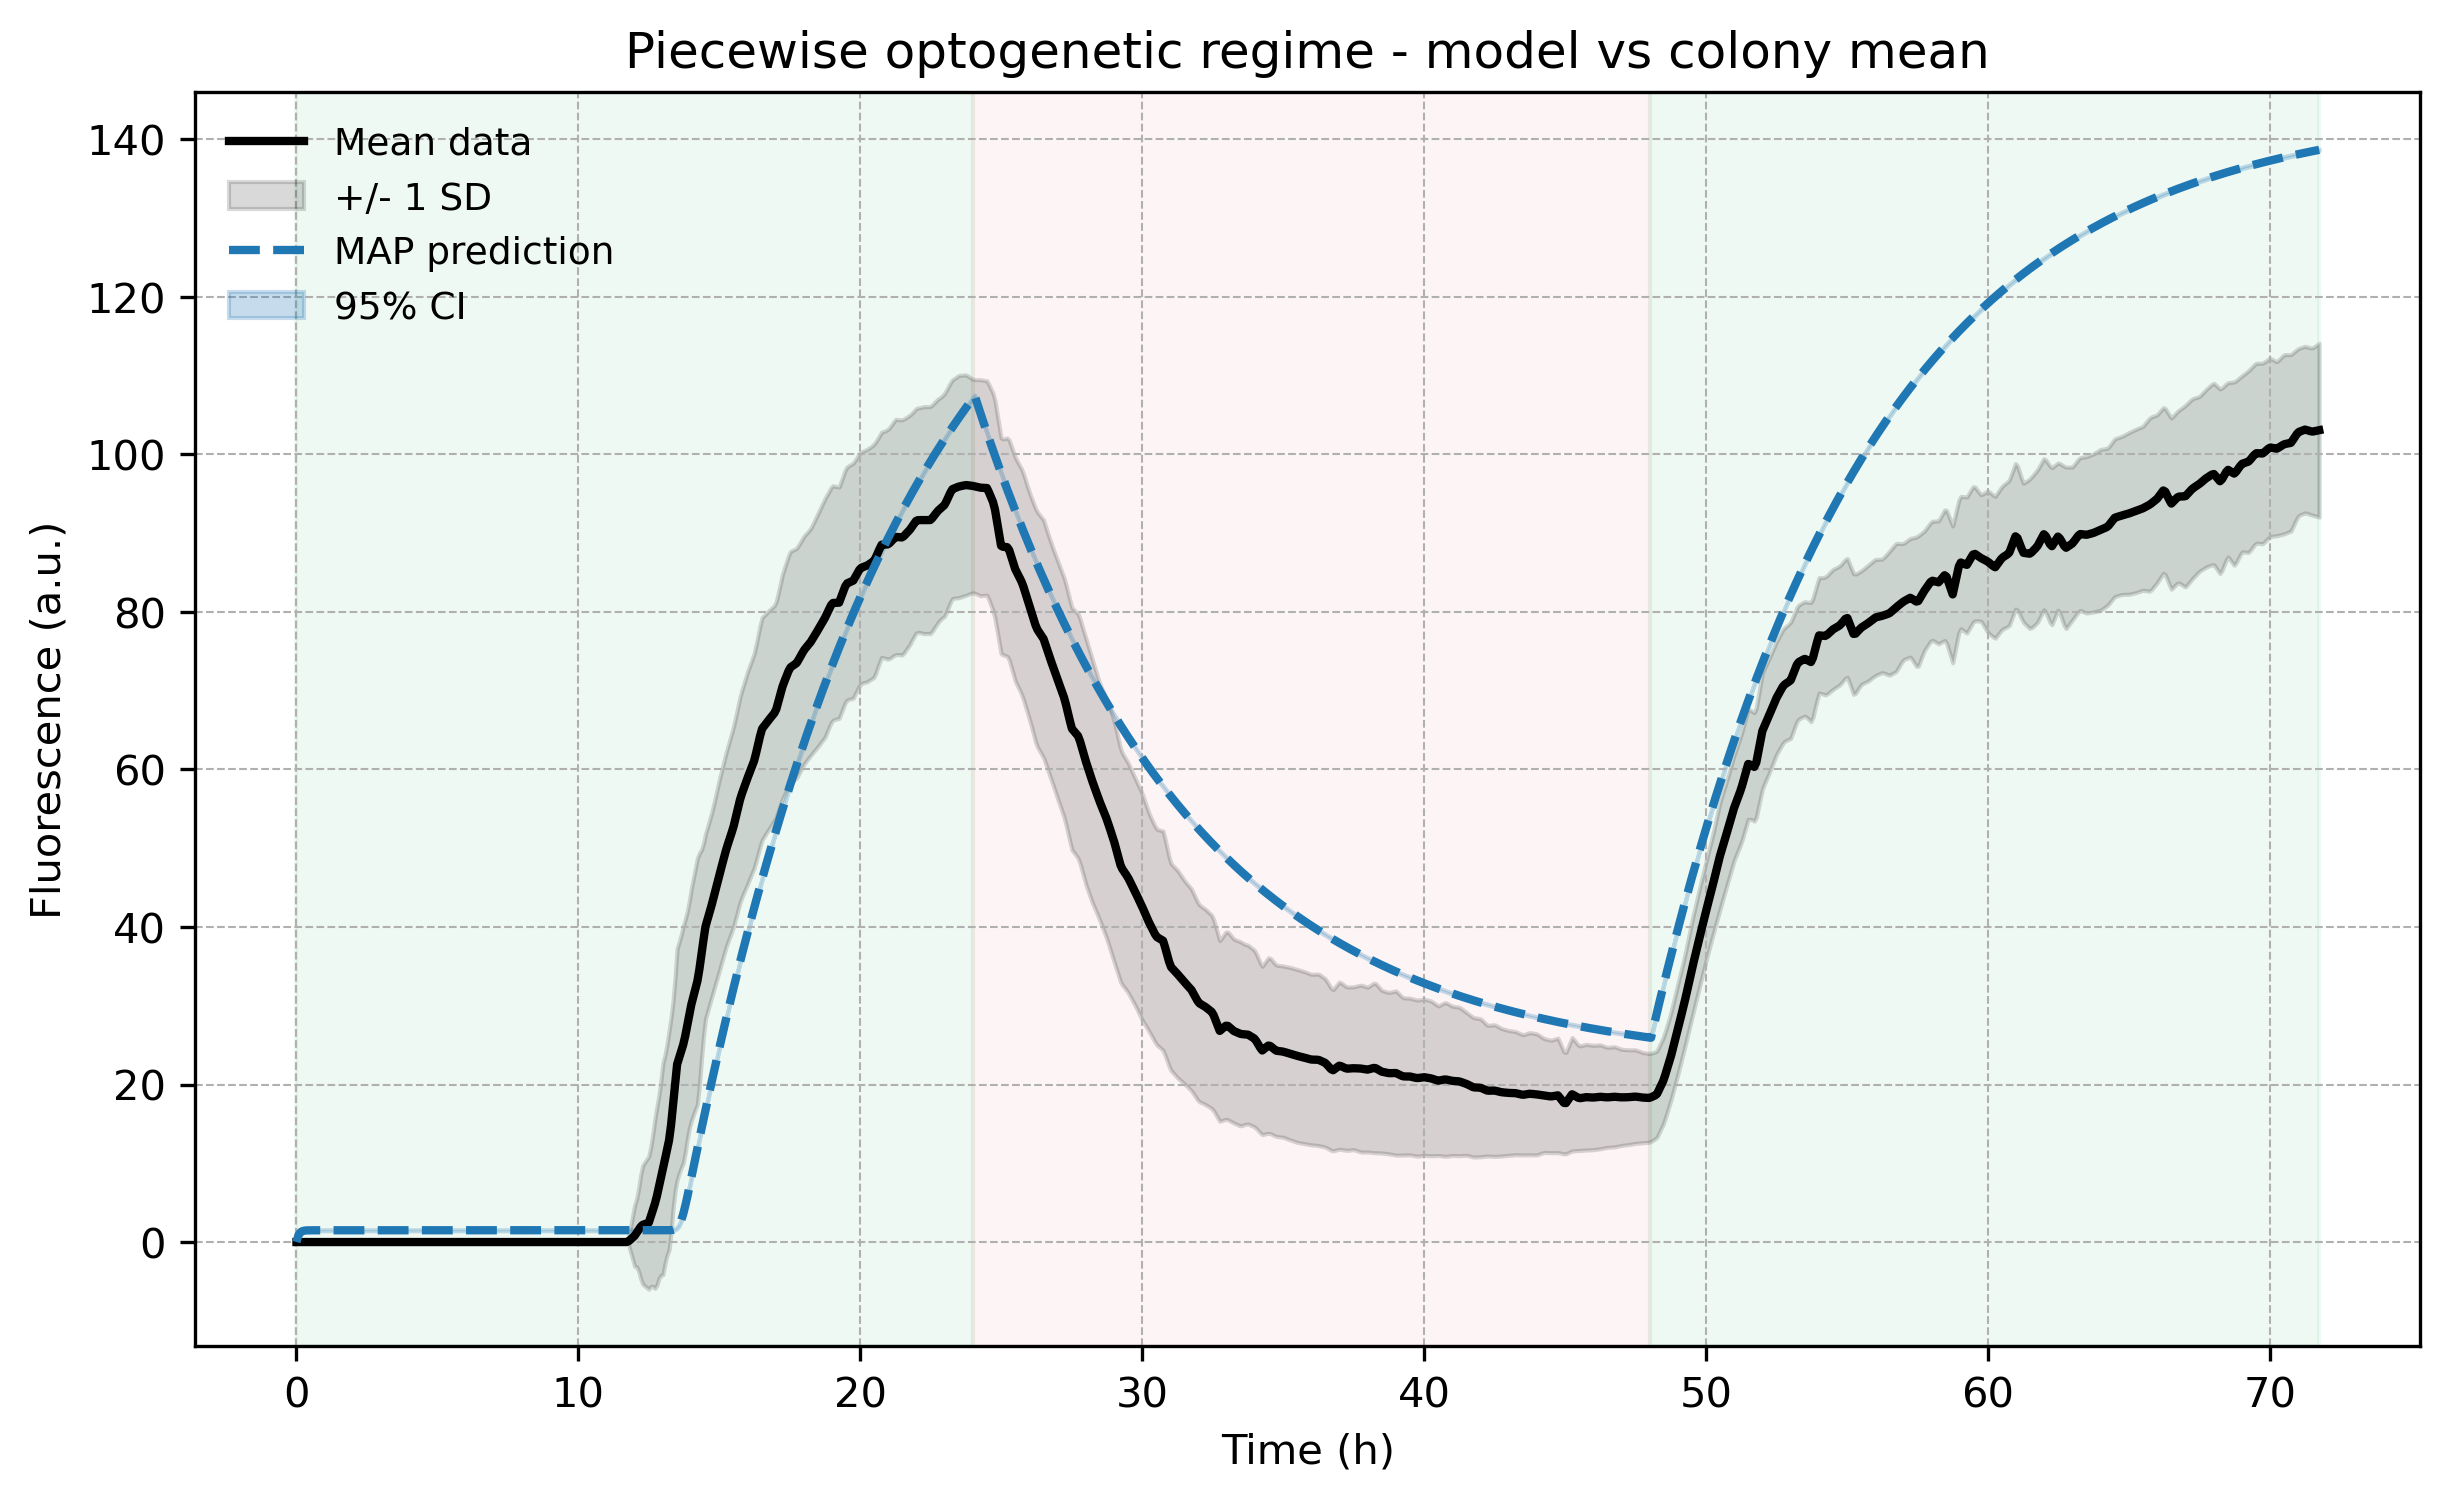

Saved per-ROI plots to 'MODEL_FIGURES/piecewise_regime_per_roi' and the mean plot to 'MODEL_FIGURES'.


In [45]:
def plot_schedule_background(ax, segments, t_max):
    """Lightly shade the green/red epochs for visual reference."""

    start = 0.0
    for end_time, g_val, r_val in segments:
        end_time = end_time if np.isfinite(end_time) else t_max
        if end_time <= start:
            continue
        color = "mediumseagreen" if g_val >= r_val else "lightcoral"
        ax.axvspan(start, end_time, color=color, alpha=0.08, zorder=0)
        start = end_time


if changing_dataset:
    rng = np.random.default_rng(42)
    funcptr = np.int64(funcptr_reduced.address)
    map_theta_lin = np.median(flat_samples_linear[:, :-1], axis=0)

    max_time = max(roi.t[-1] for roi in changing_dataset)
    common_t = np.linspace(0, max_time, 1000)

    interpolated_ys = np.array(
        [np.interp(common_t, roi.t, roi.y) for roi in changing_dataset if roi.t.size > 1]
    )
    mean_exp_y = np.mean(interpolated_ys, axis=0)
    std_exp_y = np.std(interpolated_ys, axis=0)

    I_G_common, I_R_common = build_piecewise_light_schedule(
        common_t, CHANGING_REGIME_SEGMENTS
    )
    mean_u0 = np.array([np.mean([rec.u0[0] for rec in changing_dataset])], dtype=np.float64)

    sim_roi_data = ROIData(
        common_t,
        np.array([]),
        mean_u0,
        I_G_common,
        I_R_common,
        common_t[0],
        common_t[1] - common_t[0],
    )

    n_draws = min(10000, flat_samples_linear.shape[0])
    idx = rng.choice(flat_samples_linear.shape[0], size=n_draws, replace=False)
    posterior_thetas = flat_samples_linear[idx, :-1]

    posterior_sims = np.array(
        [
            run_forward_model(theta, sim_roi_data, funcptr)
            for theta in tqdm.tqdm(
                posterior_thetas, desc="Simulating piecewise schedule"
            )
        ]
    )
    lower_ci, median_pred, upper_ci = np.percentile(posterior_sims, [2.5, 50, 97.5], axis=0)
    map_pred = run_forward_model(map_theta_lin, sim_roi_data, funcptr)

    os.makedirs("MODEL_FIGURES", exist_ok=True)
    fig, ax = plt.subplots(figsize=set_size("thesis", fraction=1.4))
    plot_schedule_background(ax, CHANGING_REGIME_SEGMENTS, t_max=common_t[-1])
    ax.plot(common_t, mean_exp_y, color="black", lw=2, label="Mean data")
    ax.fill_between(
        common_t,
        mean_exp_y - std_exp_y,
        mean_exp_y + std_exp_y,
        color="black",
        alpha=0.15,
        label="+/- 1 SD",
    )
    ax.plot(common_t, map_pred, color="C0", lw=2, ls="--", label="MAP prediction")
    ax.fill_between(
        common_t,
        lower_ci,
        upper_ci,
        color="C0",
        alpha=0.25,
        label="95% CI",
    )
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Fluorescence (a.u.)")
    ax.set_title("Piecewise optogenetic regime - model vs colony mean")
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    fig.savefig("MODEL_FIGURES/piecewise_regime_mean.png", dpi=300)
    fig.savefig("MODEL_FIGURES/piecewise_regime_mean.pdf")
    plt.show()

    per_roi_dir = os.path.join("MODEL_FIGURES", "piecewise_regime_per_roi")
    os.makedirs(per_roi_dir, exist_ok=True)

    for i, roi in enumerate(changing_dataset):
        fig, ax = plt.subplots(figsize=(6, 4))
        plot_schedule_background(ax, CHANGING_REGIME_SEGMENTS, t_max=roi.t[-1])
        ax.plot(roi.t, roi.y, "o", color="black", label="Data")
        pred = run_forward_model(map_theta_lin, roi, funcptr)
        ax.plot(roi.t, pred, color="C1", lw=2, label="MAP prediction")
        ax.set_xlabel("Time (h)")
        ax.set_ylabel("Fluorescence (a.u.)")
        ax.set_title(f"{CHANGING_REGIME_ID} - ROI {i}")
        ax.legend(frameon=False, fontsize=9)
        ax.grid(True, which="both", linestyle="--", linewidth=0.5)
        plt.tight_layout()

        outfile_base = os.path.join(per_roi_dir, f"{CHANGING_REGIME_ID}_ROI_{i}")
        fig.savefig(f"{outfile_base}.png", dpi=300)
        fig.savefig(f"{outfile_base}.pdf")
        plt.close(fig)

    print(
        "Saved per-ROI plots to 'MODEL_FIGURES/piecewise_regime_per_roi' and the mean plot to 'MODEL_FIGURES'."
    )
else:
    print("Skipping changing-regime plots; no ROIs were loaded.")


In [46]:
r2_stats

{'r2_classical': 0.6457684818241392,
 'r2_bayesian': 0.8602842846683814,
 'r2_predictive': 0.9879359186847734,
 'r2_per_dataset': {'CHANGING_REGIME': 0.6457684818241392},
 'n_observations': 7200,
 'rmse': 22.15060434236291}

In [47]:
# R² for the changing-regime dataset (posterior ensemble)
if changing_dataset:
    funcptr = np.int64(funcptr_reduced.address)
    r2_stats = compute_r2_bayesian(
        {"CHANGING_REGIME": changing_dataset},
        flat_samples_linear,
        funcptr,
        N_SAMPLES=2000,   # adjust if you want more/less posterior draws
        seed=42,
    )
    print("R² (posterior mean over draws):", r2_stats.get("CHANGING_REGIME"))
else:
    print("No changing-regime ROIs available for R².")


R² (posterior mean over draws): None


In [48]:
if changing_dataset:
    funcptr = np.int64(funcptr_reduced.address)
    map_theta_lin = np.median(flat_samples_linear[:, :-1], axis=0)

    y_obs, y_pred = [], []
    for roi in changing_dataset:
        pred = run_forward_model(map_theta_lin, roi, funcptr)
        if np.all(np.isfinite(pred)):
            y_obs.extend(roi.y)
            y_pred.extend(pred)

    y_obs = np.array(y_obs); y_pred = np.array(y_pred)
    sse = np.sum((y_obs - y_pred) ** 2)
    sst = np.sum((y_obs - y_obs.mean()) ** 2)
    r2_map = 1.0 - sse / sst
    print(f"MAP R² (pred vs exp): {r2_map:.3f}")

MAP R² (pred vs exp): 0.646
